# 準備

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# !pip3 install japanize-matplotlib
import japanize_matplotlib
import numpy as np

## CSV読み込み

In [3]:
df_click_logs = pd.read_csv('../data/click_logs.csv')
df_selected_rows = pd.read_csv('../data/selected_rows.csv')

In [4]:
df_click_logs['occurred_at_jst'] = pd.to_datetime(df_click_logs['occurred_at_jst'])
df_selected_rows['updated_at'] = pd.to_datetime(df_selected_rows['updated_at'])

df_session_task = df_selected_rows[['session_id', 'task', 'correct', 'experience', 'updated_at']].copy()

df_session_task_unique = df_session_task.drop_duplicates()
df_session_task_unique = df_session_task_unique[df_session_task_unique['correct'].notna()]
display(df_session_task_unique)

,session_id,task,correct,experience,updated_at
15,bde3507b-3728-44b7-b8f7-6166f7ff1c45,duplicate,True,2.0,2025-12-04 14:00:25
20,af542900-d8bb-4dbb-abb9-bcac66c09818,exceed,True,1.0,2025-12-09 16:25:48
21,6ff3d032-dcaf-49ea-971c-1e2942572b61,duplicate,True,1.5,2025-12-09 18:17:40
33,df5c4117-7c69-426d-b3b9-b76f2738e039,exceed,False,1.0,2025-12-09 18:33:20
38,0c9ba487-5f65-48a3-a4a4-2c4d9811faaf,duplicate,True,1.0,2025-12-15 11:03:05
41,2d306479-3cf0-4ebe-9e25-7e062739c5a4,exceed,False,2.0,2025-12-15 16:42:45
42,e87a9bda-7533-4de0-be74-82f20f3de114,duplicate,False,0.5,2025-12-16 11:04:34
48,6cab2260-984a-437d-a90b-42ea2b4b2548,exceed,True,6.0,2025-12-16 16:30:12
52,9eb03933-a8cc-4f0f-a071-346af4ce2d01,duplicate,False,2.0,2025-12-18 11:19:53
55,978a7f0f-7dbf-44c1-b69e-9cda7be9011e,exceed,True,3.0,2025-12-18 13:07:23


In [5]:
# データフレーム結合
df_merged = pd.merge(df_click_logs, df_session_task_unique, on='session_id', how='inner')

# session_idsリストに含まれるsession_idのみでフィルタリング
# df_experiment = df_merged[df_merged['session_id'].isin(session_ids)]
df_experiment = df_merged.copy()

df_experiment = df_experiment.sort_values(by=['occurred_at_jst']).reset_index(drop=True)
df_experiment['stay_time'] = df_experiment.groupby('session_id')['occurred_at_jst'].diff(-1).dt.total_seconds().abs().fillna(0)

In [6]:
last_time = df_experiment.groupby("session_id")["occurred_at_jst"].last()

stay_time = (
    df_session_task_unique.set_index("session_id")["updated_at"]
    .sub(last_time)
    .dt.total_seconds()
)

last_idx = df_experiment.groupby("session_id").tail(1).index
df_experiment.loc[last_idx, "stay_time"] = (
    df_experiment.loc[last_idx, "session_id"].map(stay_time)
)


display(df_experiment)

,session_id,event_type,location,occurred_at_jst,task,correct,experience,updated_at,stay_time
0,bde3507b-3728-44b7-b8f7-6166f7ff1c45,file,book.py,2025-12-04 13:47:49,duplicate,True,2.0,2025-12-04 14:00:25,7.0
1,bde3507b-3728-44b7-b8f7-6166f7ff1c45,file,member.py,2025-12-04 13:47:56,duplicate,True,2.0,2025-12-04 14:00:25,1.0
2,bde3507b-3728-44b7-b8f7-6166f7ff1c45,file,library.py,2025-12-04 13:47:57,duplicate,True,2.0,2025-12-04 14:00:25,3.0
3,bde3507b-3728-44b7-b8f7-6166f7ff1c45,file,main.py,2025-12-04 13:48:00,duplicate,True,2.0,2025-12-04 14:00:25,44.0
4,bde3507b-3728-44b7-b8f7-6166f7ff1c45,file,book.py,2025-12-04 13:48:44,duplicate,True,2.0,2025-12-04 14:00:25,4.0
...,...,...,...,...,...,...,...,...,...
1442,e0bb1d9d-32da-46b5-92cb-084590425dbe,check,Book.__init__-line-10,2026-01-13 14:51:18,duplicate,True,0.5,2026-01-13 14:52:28,9.0
1443,e0bb1d9d-32da-46b5-92cb-084590425dbe,method,Book.__del__,2026-01-13 14:51:27,duplicate,True,0.5,2026-01-13 14:52:28,25.0
1444,e0bb1d9d-32da-46b5-92cb-084590425dbe,method,Book.__init__,2026-01-13 14:51:52,duplicate,True,0.5,2026-01-13 14:52:28,19.0
1445,e0bb1d9d-32da-46b5-92cb-084590425dbe,method,Book.__del__,2026-01-13 14:52:11,duplicate,True,0.5,2026-01-13 14:52:28,2.0


## stay_time の分布確認

In [7]:
# stay_time が 3秒未満の行数を確認
total_rows = len(df_experiment)
rows_less_than_3s = len(df_experiment[df_experiment['stay_time'] < 3])
percentage_less_than_3s = (rows_less_than_3s / total_rows) * 100

print(f"df_experiment の全行数: {total_rows:,}")
print(f"stay_time が 3秒未満の行数: {rows_less_than_3s:,}")
print(f"割合: {percentage_less_than_3s:.2f}%")
print()

# 詳細な分布を確認
print("stay_time の分布:")
print(f"  0秒 (0s): {len(df_experiment[df_experiment['stay_time'] == 0]):,} 行")
print(f"  0秒超 1秒未満 (0-1s): {len(df_experiment[(df_experiment['stay_time'] > 0) & (df_experiment['stay_time'] < 1)]):,} 行")
print(f"  1秒以上 3秒未満 (1-3s): {len(df_experiment[(df_experiment['stay_time'] >= 1) & (df_experiment['stay_time'] < 3)]):,} 行")
print(f"  3秒以上 (≥3s): {len(df_experiment[df_experiment['stay_time'] >= 3]):,} 行")
print()

# 基本統計量
print("stay_time の基本統計量:")
print(f"  平均: {df_experiment['stay_time'].mean():.2f} 秒")
print(f"  中央値: {df_experiment['stay_time'].median():.2f} 秒")
print(f"  標準偏差: {df_experiment['stay_time'].std():.2f} 秒")
print(f"  最小値: {df_experiment['stay_time'].min():.2f} 秒")
print(f"  最大値: {df_experiment['stay_time'].max():.2f} 秒")

df_experiment の全行数: 1,447
stay_time が 3秒未満の行数: 524
割合: 36.21%

stay_time の分布:
  0秒 (0s): 26 行
  0秒超 1秒未満 (0-1s): 0 行
  1秒以上 3秒未満 (1-3s): 498 行
  3秒以上 (≥3s): 923 行

stay_time の基本統計量:
  平均: 10.59 秒
  中央値: 4.00 秒
  標準偏差: 19.76 秒
  最小値: 0.00 秒
  最大値: 346.00 秒


In [8]:
# stay_time が 0秒の行を抽出
df_stay_time_zero = df_experiment[df_experiment['stay_time'] == 2].copy()

print(f"stay_time が 0秒の行数: {len(df_stay_time_zero):,}")
print(f"全体に占める割合: {(len(df_stay_time_zero) / len(df_experiment) * 100):.2f}%")
print()

# セッションごとの0秒行の数を集計
zero_by_session = df_stay_time_zero.groupby('session_id').size().sort_values(ascending=False)
print(f"セッションごとの0秒行の分布:")
print(f"  最大: {zero_by_session.max()} 行/セッション")
print(f"  最小: {zero_by_session.min()} 行/セッション")
print(f"  平均: {zero_by_session.mean():.2f} 行/セッション")
print()

# 上位10件を表示
display(df_stay_time_zero.head(10))

stay_time が 0秒の行数: 263
全体に占める割合: 18.18%

セッションごとの0秒行の分布:
  最大: 54 行/セッション
  最小: 5 行/セッション
  平均: 17.53 行/セッション



,session_id,event_type,location,occurred_at_jst,task,correct,experience,updated_at,stay_time
6,bde3507b-3728-44b7-b8f7-6166f7ff1c45,file,library.py,2025-12-04 13:48:49,duplicate,True,2.0,2025-12-04 14:00:25,2.0
21,bde3507b-3728-44b7-b8f7-6166f7ff1c45,file,main.py,2025-12-04 13:52:07,duplicate,True,2.0,2025-12-04 14:00:25,2.0
26,bde3507b-3728-44b7-b8f7-6166f7ff1c45,file,library.py,2025-12-04 13:52:32,duplicate,True,2.0,2025-12-04 14:00:25,2.0
30,bde3507b-3728-44b7-b8f7-6166f7ff1c45,file,book.py,2025-12-04 13:53:13,duplicate,True,2.0,2025-12-04 14:00:25,2.0
32,bde3507b-3728-44b7-b8f7-6166f7ff1c45,method,Book.__del__,2025-12-04 13:53:21,duplicate,True,2.0,2025-12-04 14:00:25,2.0
41,bde3507b-3728-44b7-b8f7-6166f7ff1c45,check,Book.__init__-line-10,2025-12-04 13:56:53,duplicate,True,2.0,2025-12-04 14:00:25,2.0
45,bde3507b-3728-44b7-b8f7-6166f7ff1c45,file,library.py,2025-12-04 13:57:31,duplicate,True,2.0,2025-12-04 14:00:25,2.0
46,bde3507b-3728-44b7-b8f7-6166f7ff1c45,file,main.py,2025-12-04 13:57:33,duplicate,True,2.0,2025-12-04 14:00:25,2.0
47,bde3507b-3728-44b7-b8f7-6166f7ff1c45,file,library.py,2025-12-04 13:57:35,duplicate,True,2.0,2025-12-04 14:00:25,2.0
50,bde3507b-3728-44b7-b8f7-6166f7ff1c45,file,member.py,2025-12-04 13:57:48,duplicate,True,2.0,2025-12-04 14:00:25,2.0


## セッションごとの滞在時間統計

In [9]:
# セッションごとの滞在時間の合計を計算
session_total_stay_time = df_experiment.groupby('session_id')['stay_time'].sum()

# 平均と標準偏差を計算
mean_stay_time = session_total_stay_time.mean()
std_stay_time = session_total_stay_time.std()

print(f"セッションごとの合計滞在時間:")
print(f"  平均: {mean_stay_time:.2f} 秒 ({mean_stay_time/60:.2f} 分)")
print(f"  標準偏差: {std_stay_time:.2f} 秒 ({std_stay_time/60:.2f} 分)")
print(f"  最小値: {session_total_stay_time.min():.2f} 秒")
print(f"  最大値: {session_total_stay_time.max():.2f} 秒")
print(f"  セッション数: {len(session_total_stay_time)}")

# セッションごとの詳細を表示
session_stats = pd.DataFrame({
    '合計滞在時間(秒)': session_total_stay_time,
    '合計滞在時間(分)': session_total_stay_time / 60
}).sort_values('合計滞在時間(秒)', ascending=False)

display(session_stats)

セッションごとの合計滞在時間:
  平均: 1021.33 秒 (17.02 分)
  標準偏差: 539.51 秒 (8.99 分)
  最小値: 236.00 秒
  最大値: 2124.00 秒
  セッション数: 15


,合計滞在時間(秒),合計滞在時間(分)
session_id,,
df5c4117-7c69-426d-b3b9-b76f2738e039,2124.0,35.400000
8cec8455-6613-4479-87c5-7b2cb3ab6fe6,1641.0,27.350000
e87a9bda-7533-4de0-be74-82f20f3de114,1454.0,24.233333
8179d58a-dbc6-4b82-adfd-f08f26da7958,1402.0,23.366667
2d306479-3cf0-4ebe-9e25-7e062739c5a4,1337.0,22.283333
4813a711-2dc9-41db-9945-8b8d96addf05,1303.0,21.716667
0c9ba487-5f65-48a3-a4a4-2c4d9811faaf,1239.0,20.650000
6ff3d032-dcaf-49ea-971c-1e2942572b61,1127.0,18.783333
bde3507b-3728-44b7-b8f7-6166f7ff1c45,756.0,12.600000


/var/folders/ry/b358j0pn36g39t8rbntyw_lr0000gn/T/ipykernel_4243/3430267944.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([session_total_stay_time / 60],


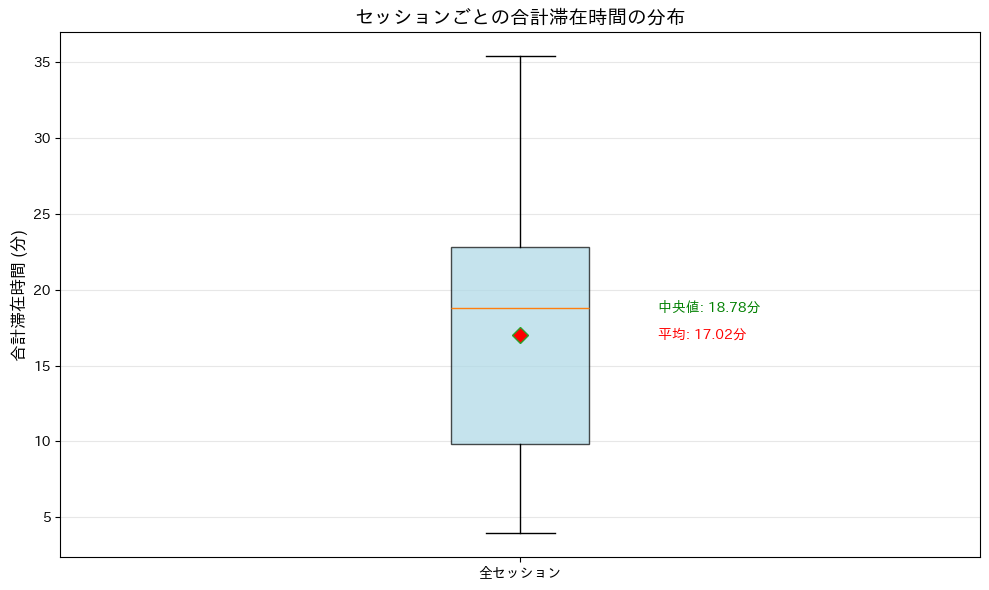

In [10]:
# 箱ひげ図を作成
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# 箱ひげ図をプロット
bp = ax.boxplot([session_total_stay_time / 60], 
                 labels=['全セッション'],
                 patch_artist=True,
                 showmeans=True,
                 meanprops=dict(marker='D', markerfacecolor='red', markersize=8, label='平均'))

# 箱の色を設定
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)

ax.set_ylabel('合計滞在時間 (分)', fontsize=12)
ax.set_title('セッションごとの合計滞在時間の分布', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')

# 平均と中央値を表示
median_val = session_total_stay_time.median() / 60
mean_val = mean_stay_time / 60
ax.text(1.15, median_val, f'中央値: {median_val:.2f}分', 
        verticalalignment='center', fontsize=10, color='green', weight='bold')
ax.text(1.15, mean_val, f'平均: {mean_val:.2f}分', 
        verticalalignment='center', fontsize=10, color='red', weight='bold')

plt.tight_layout()
plt.show()

## main.py への遷移確率

In [11]:
# main.pyへの遷移を分析
# session_idごとに前のlocationを取得
df_experiment['prev_location'] = df_experiment.groupby('session_id')['location'].shift(1)

# main.pyに遷移した行のみ抽出
df_to_main = df_experiment[df_experiment['location'] == 'main.py'].copy()

# 前のlocationの頻度を集計
transition_counts = df_to_main['prev_location'].value_counts()

# 遷移確率を計算
transition_probs = transition_counts / transition_counts.sum()

print("main.pyへの遷移確率:")
display(transition_probs.to_frame(name='probability'))

main.pyへの遷移確率:


,probability
prev_location,
library.py,0.172840
book.py,0.123457
member.py,0.098765
Library.add_book,0.092593
Library.__init__,0.086420
Book.__init__,0.080247
Library.borrow_book,0.067901
Library.return_book,0.043210
Book.__str__,0.030864


# 全データを分析

## データ前処理

In [13]:
# 平均訪問割合計算用に各セッションの先頭10行を除外

df_experiment_trimmed = (
    df_experiment
    .groupby('session_id', group_keys=False)
    .apply(lambda g: g.iloc[10:])
)

# コメントアウト
df_experiment_trimmed = df_experiment.copy()

/var/folders/ry/b358j0pn36g39t8rbntyw_lr0000gn/T/ipykernel_4243/1319845216.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_experiment


In [14]:

filtered_df_experiment_exceed = df_experiment_trimmed[
    (df_experiment_trimmed['event_type'].isin(['method', 'file'])) & 
    (df_experiment_trimmed['task'] == 'exceed') 
]
df_exceed = filtered_df_experiment_exceed.groupby(['session_id', 'location'])['stay_time'].sum().unstack(fill_value=0).T

filtered_df_experiment_duplicate = df_experiment_trimmed[
    (df_experiment_trimmed['event_type'].isin(['method', 'file'])) & 
    (df_experiment_trimmed['task'] == 'duplicate') 
]
df_duplicate = filtered_df_experiment_duplicate.groupby(['session_id', 'location'])['stay_time'].sum().unstack(fill_value=0).T

Exceed タスクの総セッション数: 7


/var/folders/ry/b358j0pn36g39t8rbntyw_lr0000gn/T/ipykernel_4243/245743154.py:115: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=12)
/var/folders/ry/b358j0pn36g39t8rbntyw_lr0000gn/T/ipykernel_4243/245743154.py:115: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=12)
/var/folders/ry/b358j0pn36g39t8rbntyw_lr0000gn/T/ipykernel_4243/245743154.py:115: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=12)
/var/folders/ry/b358j0pn36g39t8rbntyw_lr0000gn/T/ipykernel_4243/245743154.py:115: UserWarning: No artists with l

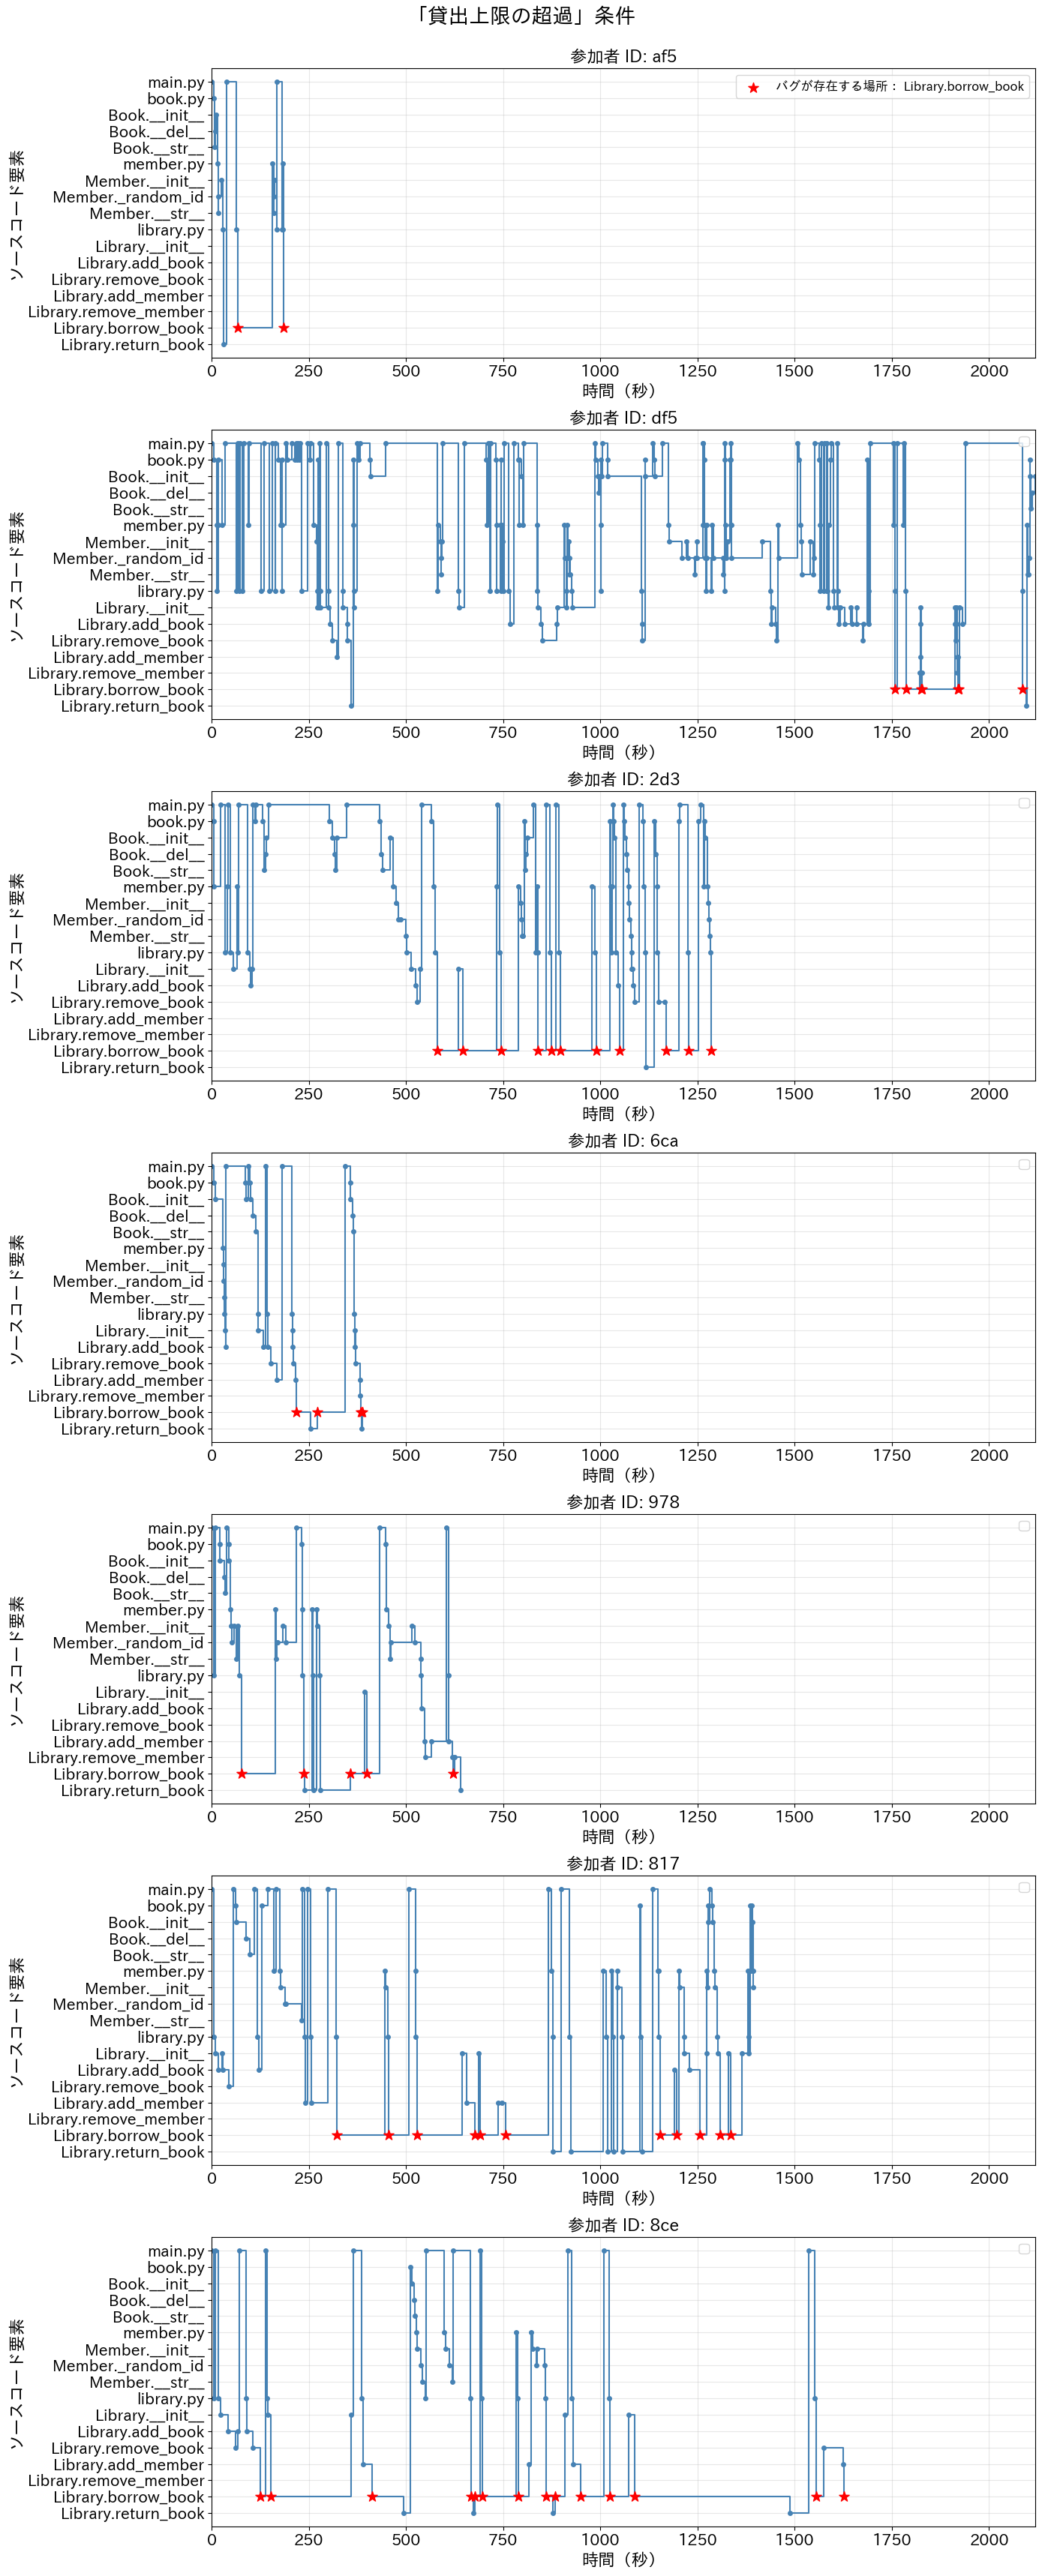

Duplicate タスクの総セッション数: 8


/var/folders/ry/b358j0pn36g39t8rbntyw_lr0000gn/T/ipykernel_4243/245743154.py:115: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=12)
/var/folders/ry/b358j0pn36g39t8rbntyw_lr0000gn/T/ipykernel_4243/245743154.py:115: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=12)
/var/folders/ry/b358j0pn36g39t8rbntyw_lr0000gn/T/ipykernel_4243/245743154.py:115: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=12)
/var/folders/ry/b358j0pn36g39t8rbntyw_lr0000gn/T/ipykernel_4243/245743154.py:115: UserWarning: No artists with l

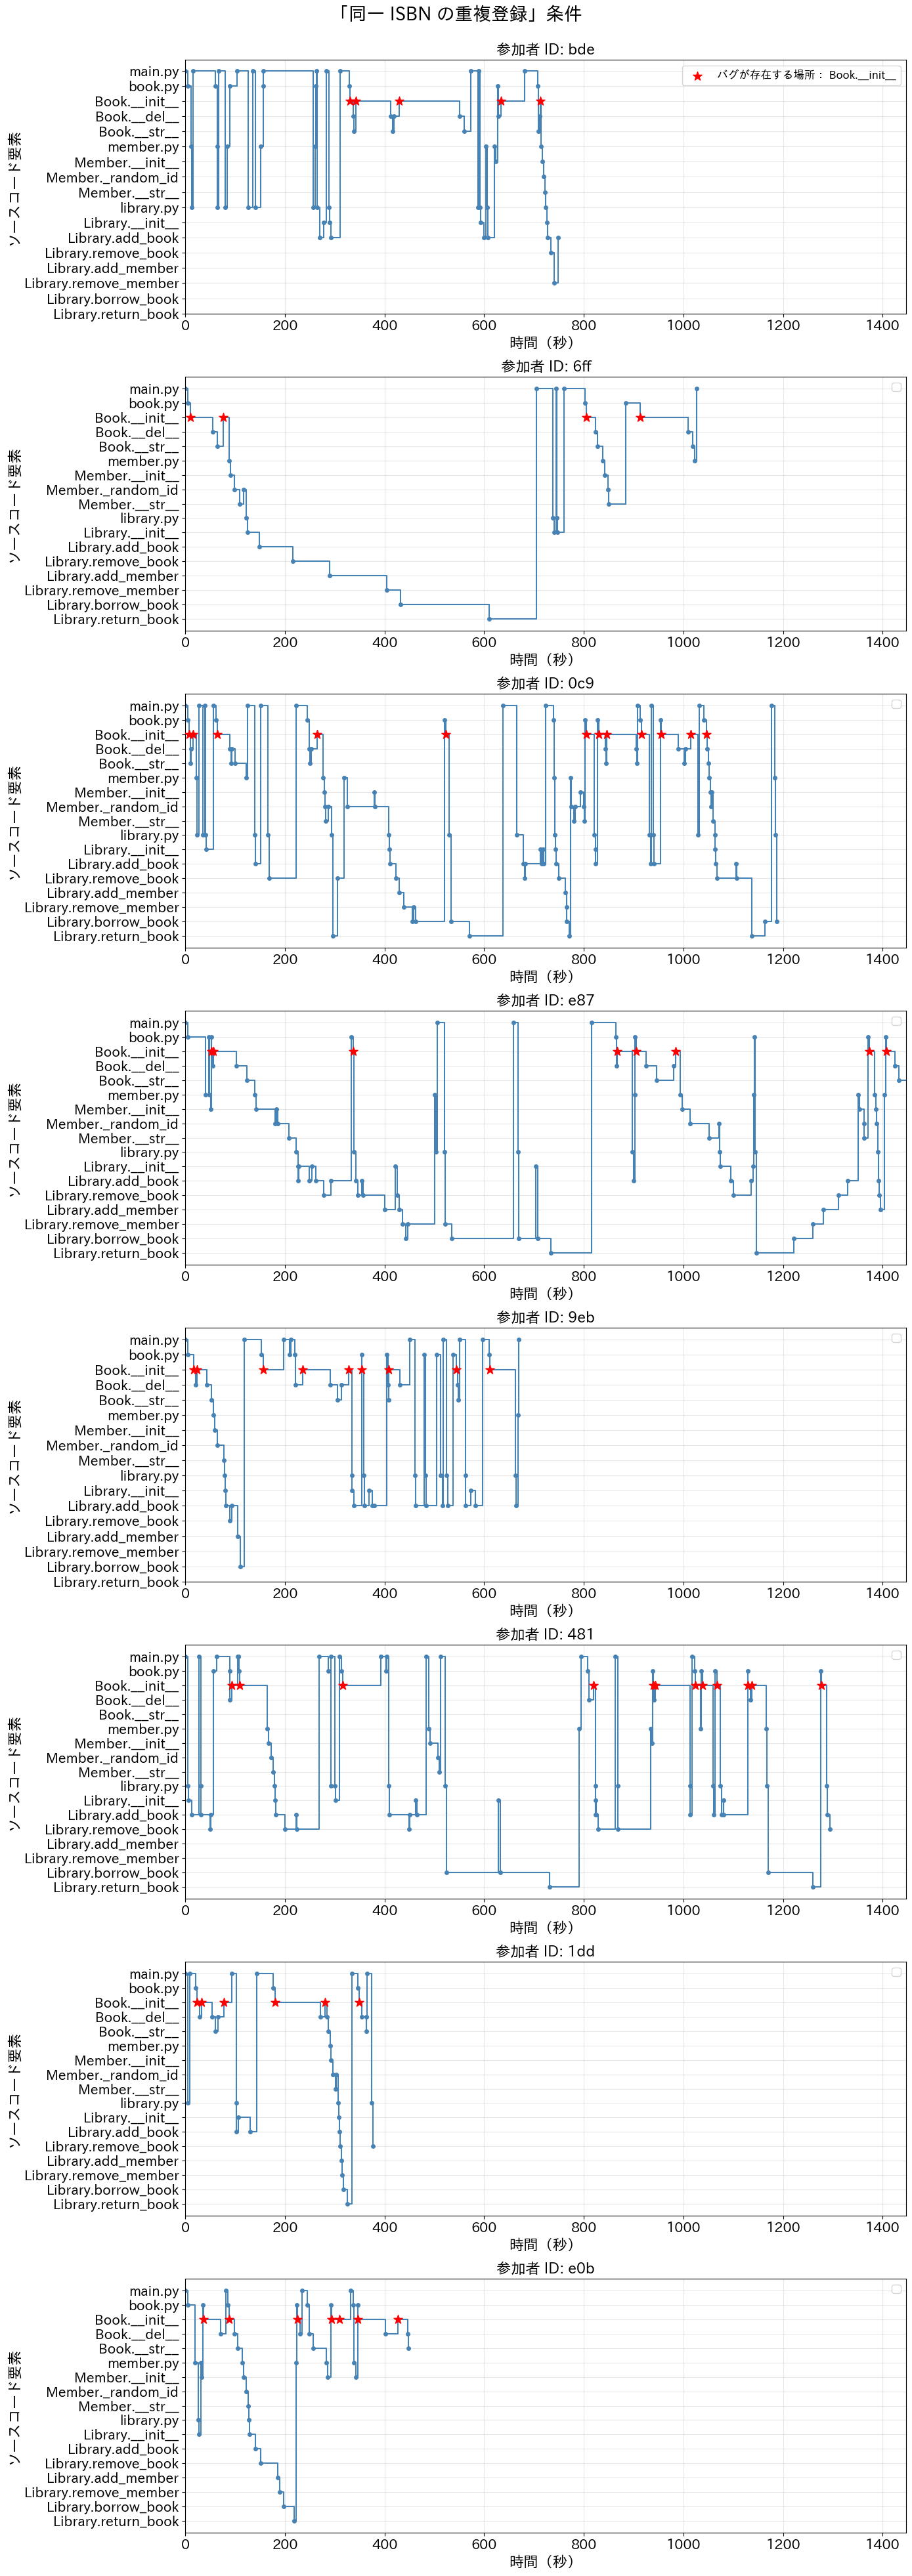

In [23]:
## タスクごとの location 遷移を可視化（stay_time >= 4秒のみ）

# topology_nodes.json の順序を定義
topology_order = [
    "main.py",
    "book.py",
    "Book.__init__",
    "Book.__del__",
    "Book.__str__",
    "member.py",
    "Member.__init__",
    "Member._random_id",
    "Member.__str__",
    "library.py",
    "Library.__init__",
    "Library.add_book",
    "Library.remove_book",
    "Library.add_member",
    "Library.remove_member",
    "Library.borrow_book",
    "Library.return_book"
]

def plot_task_transitions(df_filtered, task_name, target_location=None, n_sessions=5):
    """
    タスクごとのlocation遷移を可視化する関数
    target_location: ハイライトする対象のlocation（例：'Book.__init__'）
    """
    # タスクラベルの日本語表記
    task_labels = {
        'duplicate': '「同一 ISBN の重複登録」条件',
        'exceed': '「貸出上限の超過」条件'
    }
    
    df_task = df_filtered.copy()
    
    # topology_orderに存在するlocationのみをフィルタリング
    unique_locations = [loc for loc in topology_order if loc in df_task['location'].unique()]
    location_to_y = {loc: i for i, loc in enumerate(unique_locations)}
    
    # セッション数を確認
    session_ids = df_task['session_id'].unique()
    print(f"{task_name} タスクの総セッション数: {len(session_ids)}")
    
    # 指定数のセッションを可視化
    n_sessions_to_plot = min(n_sessions, len(session_ids))
    
    # 横軸の時間を統一するために、全セッションの最大時間を計算
    max_time = 0
    for session_id in session_ids[:n_sessions_to_plot]:
        session_data = df_task[df_task['session_id'] == session_id].copy()
        session_data = session_data.sort_values('occurred_at_jst').reset_index(drop=True)
        min_time = session_data['occurred_at_jst'].min()
        time_seconds = (session_data['occurred_at_jst'] - min_time).dt.total_seconds()
        max_time = max(max_time, time_seconds.max())
    
    fig, axes = plt.subplots(n_sessions_to_plot, 1, figsize=(14, 5 * n_sessions_to_plot))
    if n_sessions_to_plot == 1:
        axes = [axes]
    
    # ラベルを最初の1回だけ表示するためのフラグ
    label_shown = False
    
    for idx, session_id in enumerate(session_ids[:n_sessions_to_plot]):
        session_data = df_task[df_task['session_id'] == session_id].copy()
        session_data = session_data.sort_values('occurred_at_jst').reset_index(drop=True)
        
        # 時間を秒単位で正規化
        min_time = session_data['occurred_at_jst'].min()
        session_data['time_seconds'] = (session_data['occurred_at_jst'] - min_time + pd.Timedelta(seconds=5)).dt.total_seconds()

        # location を数値に変換
        session_data['location_y'] = session_data['location'].map(location_to_y)
        
        # 先頭に 0 を追加してプロット用配列を作成
        plot_time_seconds = np.insert(session_data['time_seconds'].to_numpy(), 0, 0)
        plot_location_y = np.insert(session_data['location_y'].to_numpy(), 0, 0)
        
        # プロット
        ax = axes[idx]
        
        # メインのラインをプロット
        ax.plot(plot_time_seconds, plot_location_y, 
                drawstyle='steps-post', marker='o', markersize=4, linewidth=1.5, color='steelblue')
        
        # target_locationに到達した点を赤色でハイライト
        if target_location is not None:
            target_mask = session_data['location'] == target_location
            if target_mask.any():
                # 最初の1回だけラベルを設定
                scatter_label = f'バグが存在する場所： {target_location}' if not label_shown else None
                ax.scatter(session_data[target_mask]['time_seconds'], 
                          session_data[target_mask]['location_y'],
                          color='red', s=100, marker='*', zorder=5, label=scatter_label)
                label_shown = True
        
        # Y軸のラベルを location 名に（topology_order の順序）
        ax.set_yticks(list(location_to_y.values()))
        ax.set_yticklabels(list(location_to_y.keys()), fontsize=15)
        
        # Y軸を反転して上から下に main から始まるようにする
        ax.invert_yaxis()
        
        # X軸の範囲を統一
        ax.set_xlim(0, max_time)
        
        ax.set_xlabel('時間（秒）', fontsize=16)
        ax.set_ylabel('ソースコード要素', fontsize=16)
        ax.set_title(f'参加者 ID: {session_id[:3]}', fontsize=16, fontweight='bold')
        ax.tick_params(axis='x', labelsize=15)
        ax.grid(True, alpha=0.3)
        
        # レジェンドを表示
        if target_location is not None:
            ax.legend(loc='upper right', fontsize=12)
    
    # supertitleにタスク条件名を表示
    task_key = task_name.lower() if task_name.lower() in task_labels else task_name
    fig.suptitle(task_labels.get(task_key, task_name), fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

# Exceed タスクの可視化（Library.borrow_bookをハイライト）
plot_task_transitions(filtered_df_experiment_exceed, 'Exceed', target_location='Library.borrow_book', n_sessions=7)

# Duplicate タスクの可視化（Book.__init__をハイライト）
plot_task_transitions(filtered_df_experiment_duplicate, 'Duplicate', target_location='Book.__init__', n_sessions=8)

In [27]:
def remove_ordered_transitions(df, topology_order, min_length=3):
    """
    topology_order に従って連続する遷移（min_length以上）を削除する。

    Parameters:
    - df: フィルタ済みDataFrame（session_id, occurred_at_jst, locationを含む想定）
    - topology_order: ノードの順序リスト
    - min_length: 連続とみなす最小長（デフォルト3）

    Returns:
    - 削除後のDataFrame（インデックスはリセット）
    """
    location_index = {loc: i for i, loc in enumerate(topology_order)}
    indices_to_drop = set()

    for session_id in df['session_id'].unique():
        session_df = df[df['session_id'] == session_id].sort_values('occurred_at_jst')
        locs = session_df['location'].tolist()
        idxs = session_df.index.tolist()  # 元のインデックスを保持

        i = 0
        while i < len(locs):
            loc = locs[i]
            if loc not in location_index:
                i += 1
                continue

            current_idx = location_index[loc]
            j = i + 1
            while j < len(locs):
                next_loc = locs[j]
                if next_loc not in location_index:
                    break
                next_idx = location_index[next_loc]
                if next_idx == current_idx + 1:
                    current_idx = next_idx
                    j += 1
                else:
                    break

            run_len = j - i
            if run_len >= min_length:
                indices_to_drop.update(idxs[i:j])

            i = max(j, i + 1)

    result_df = df.drop(list(indices_to_drop), errors='ignore').reset_index(drop=True)
    print(f"削除された行数: {len(indices_to_drop)}")
    print(f"元の行数: {len(df)}, 処理後の行数: {len(result_df)}")
    return result_df

# filtered_df_experiment_exceed と filtered_df_experiment_duplicate に対して処理を実行
filtered_df_experiment_exceed_cleaned = remove_ordered_transitions(
    filtered_df_experiment_exceed, topology_order, min_length=3
)
filtered_df_experiment_duplicate_cleaned = remove_ordered_transitions(
    filtered_df_experiment_duplicate, topology_order, min_length=3
)


削除された行数: 187
元の行数: 711, 処理後の行数: 524
削除された行数: 293
元の行数: 618, 処理後の行数: 325


Exceed (cleaned) セッション数: 7
Duplicate (cleaned) セッション数: 8
Exceed (cleaned) タスクの総セッション数: 7


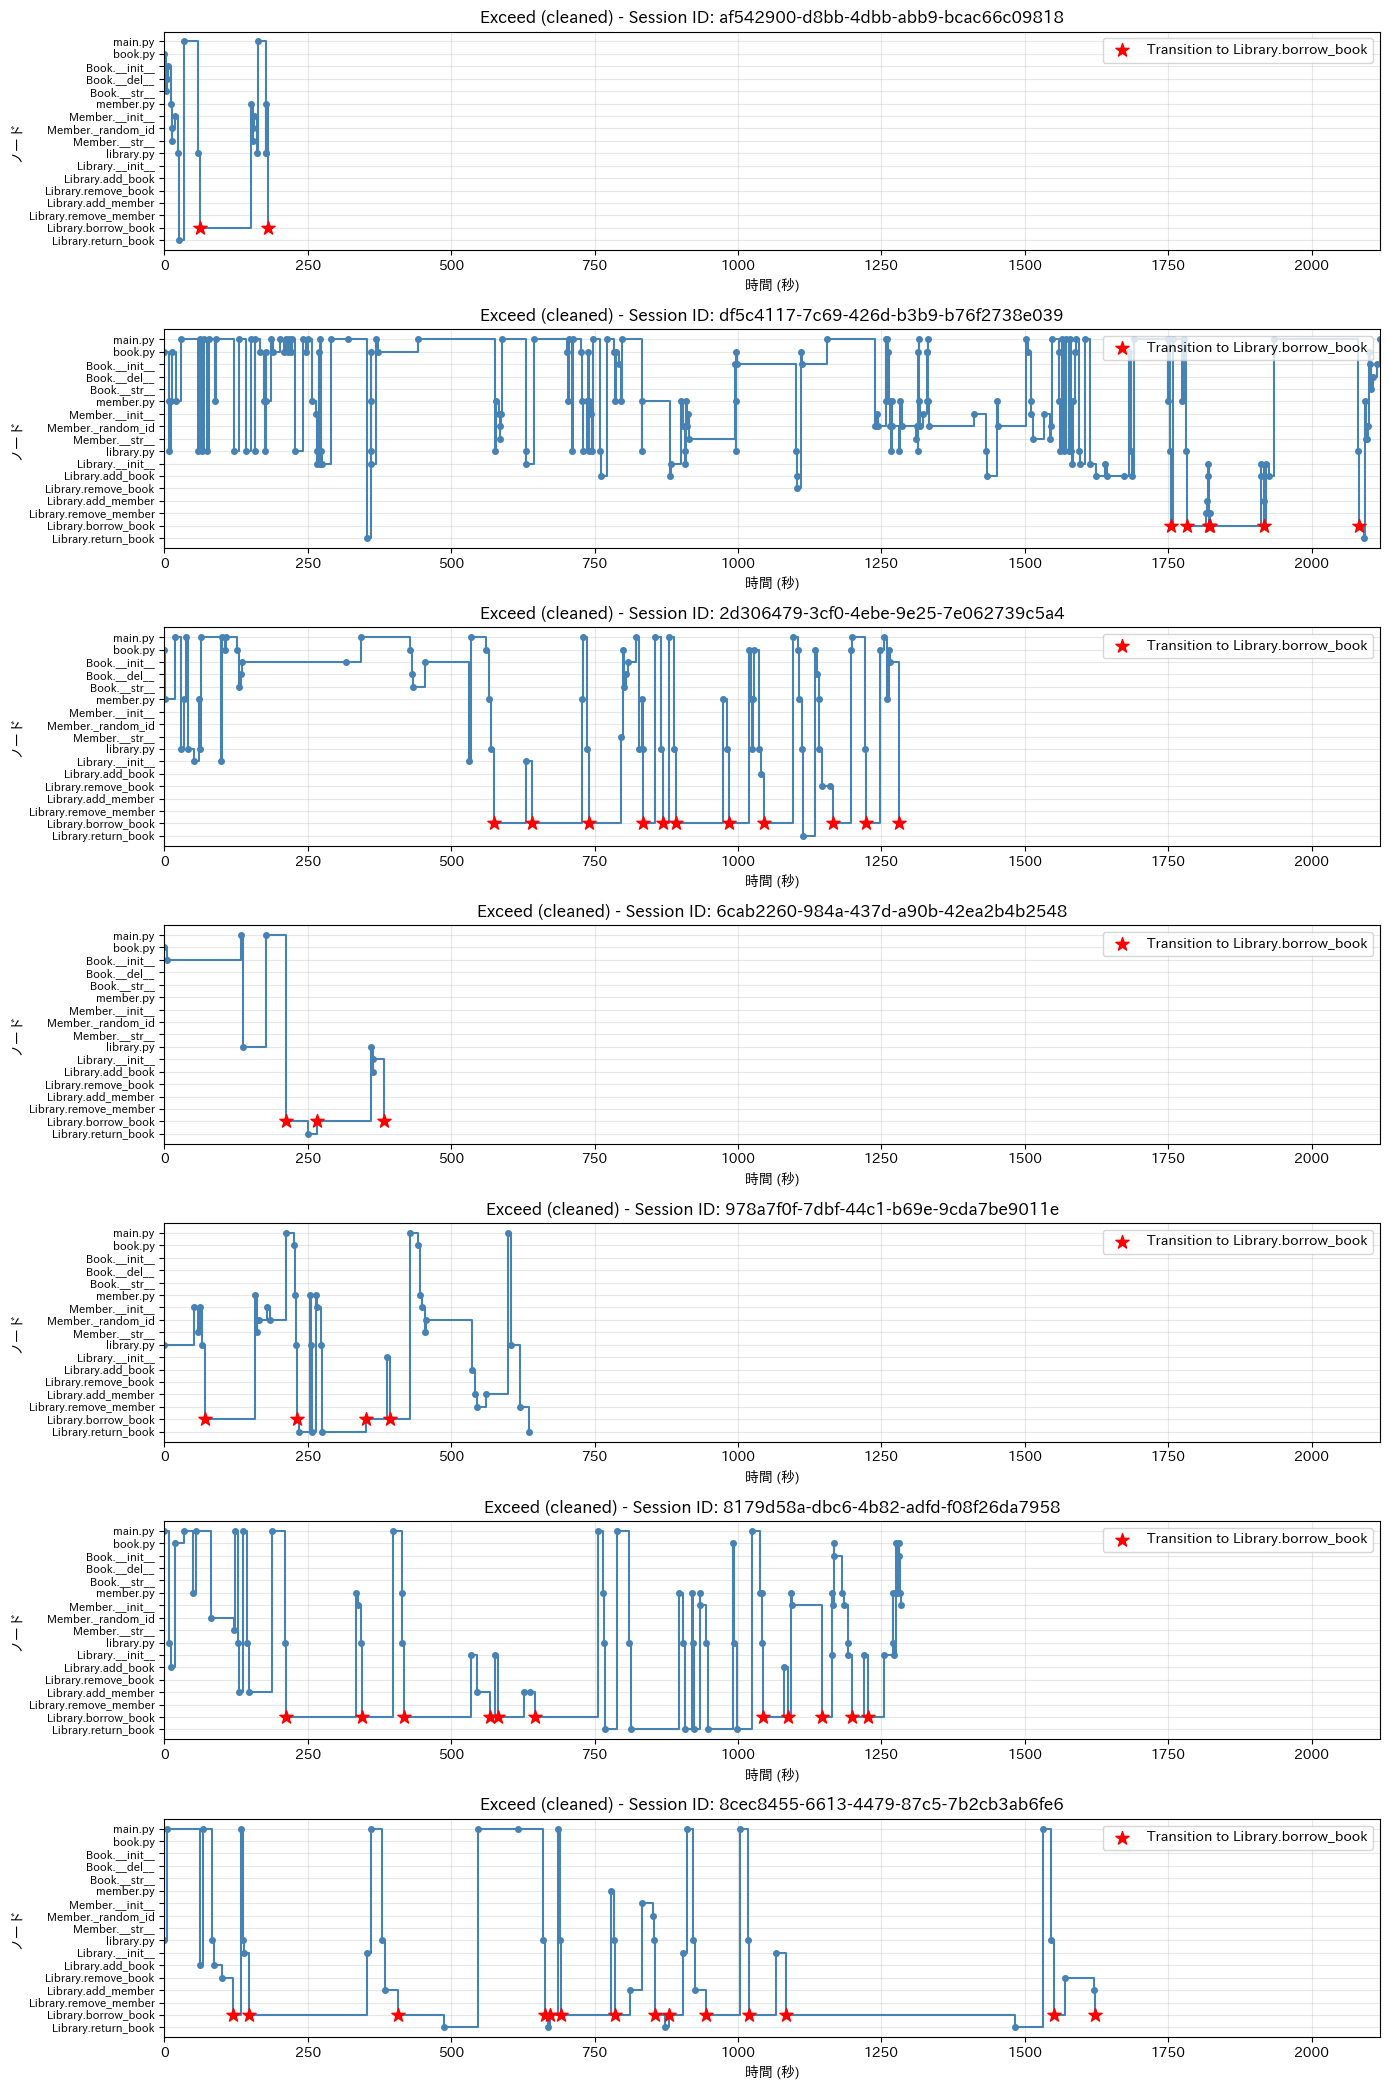

Duplicate (cleaned) タスクの総セッション数: 8


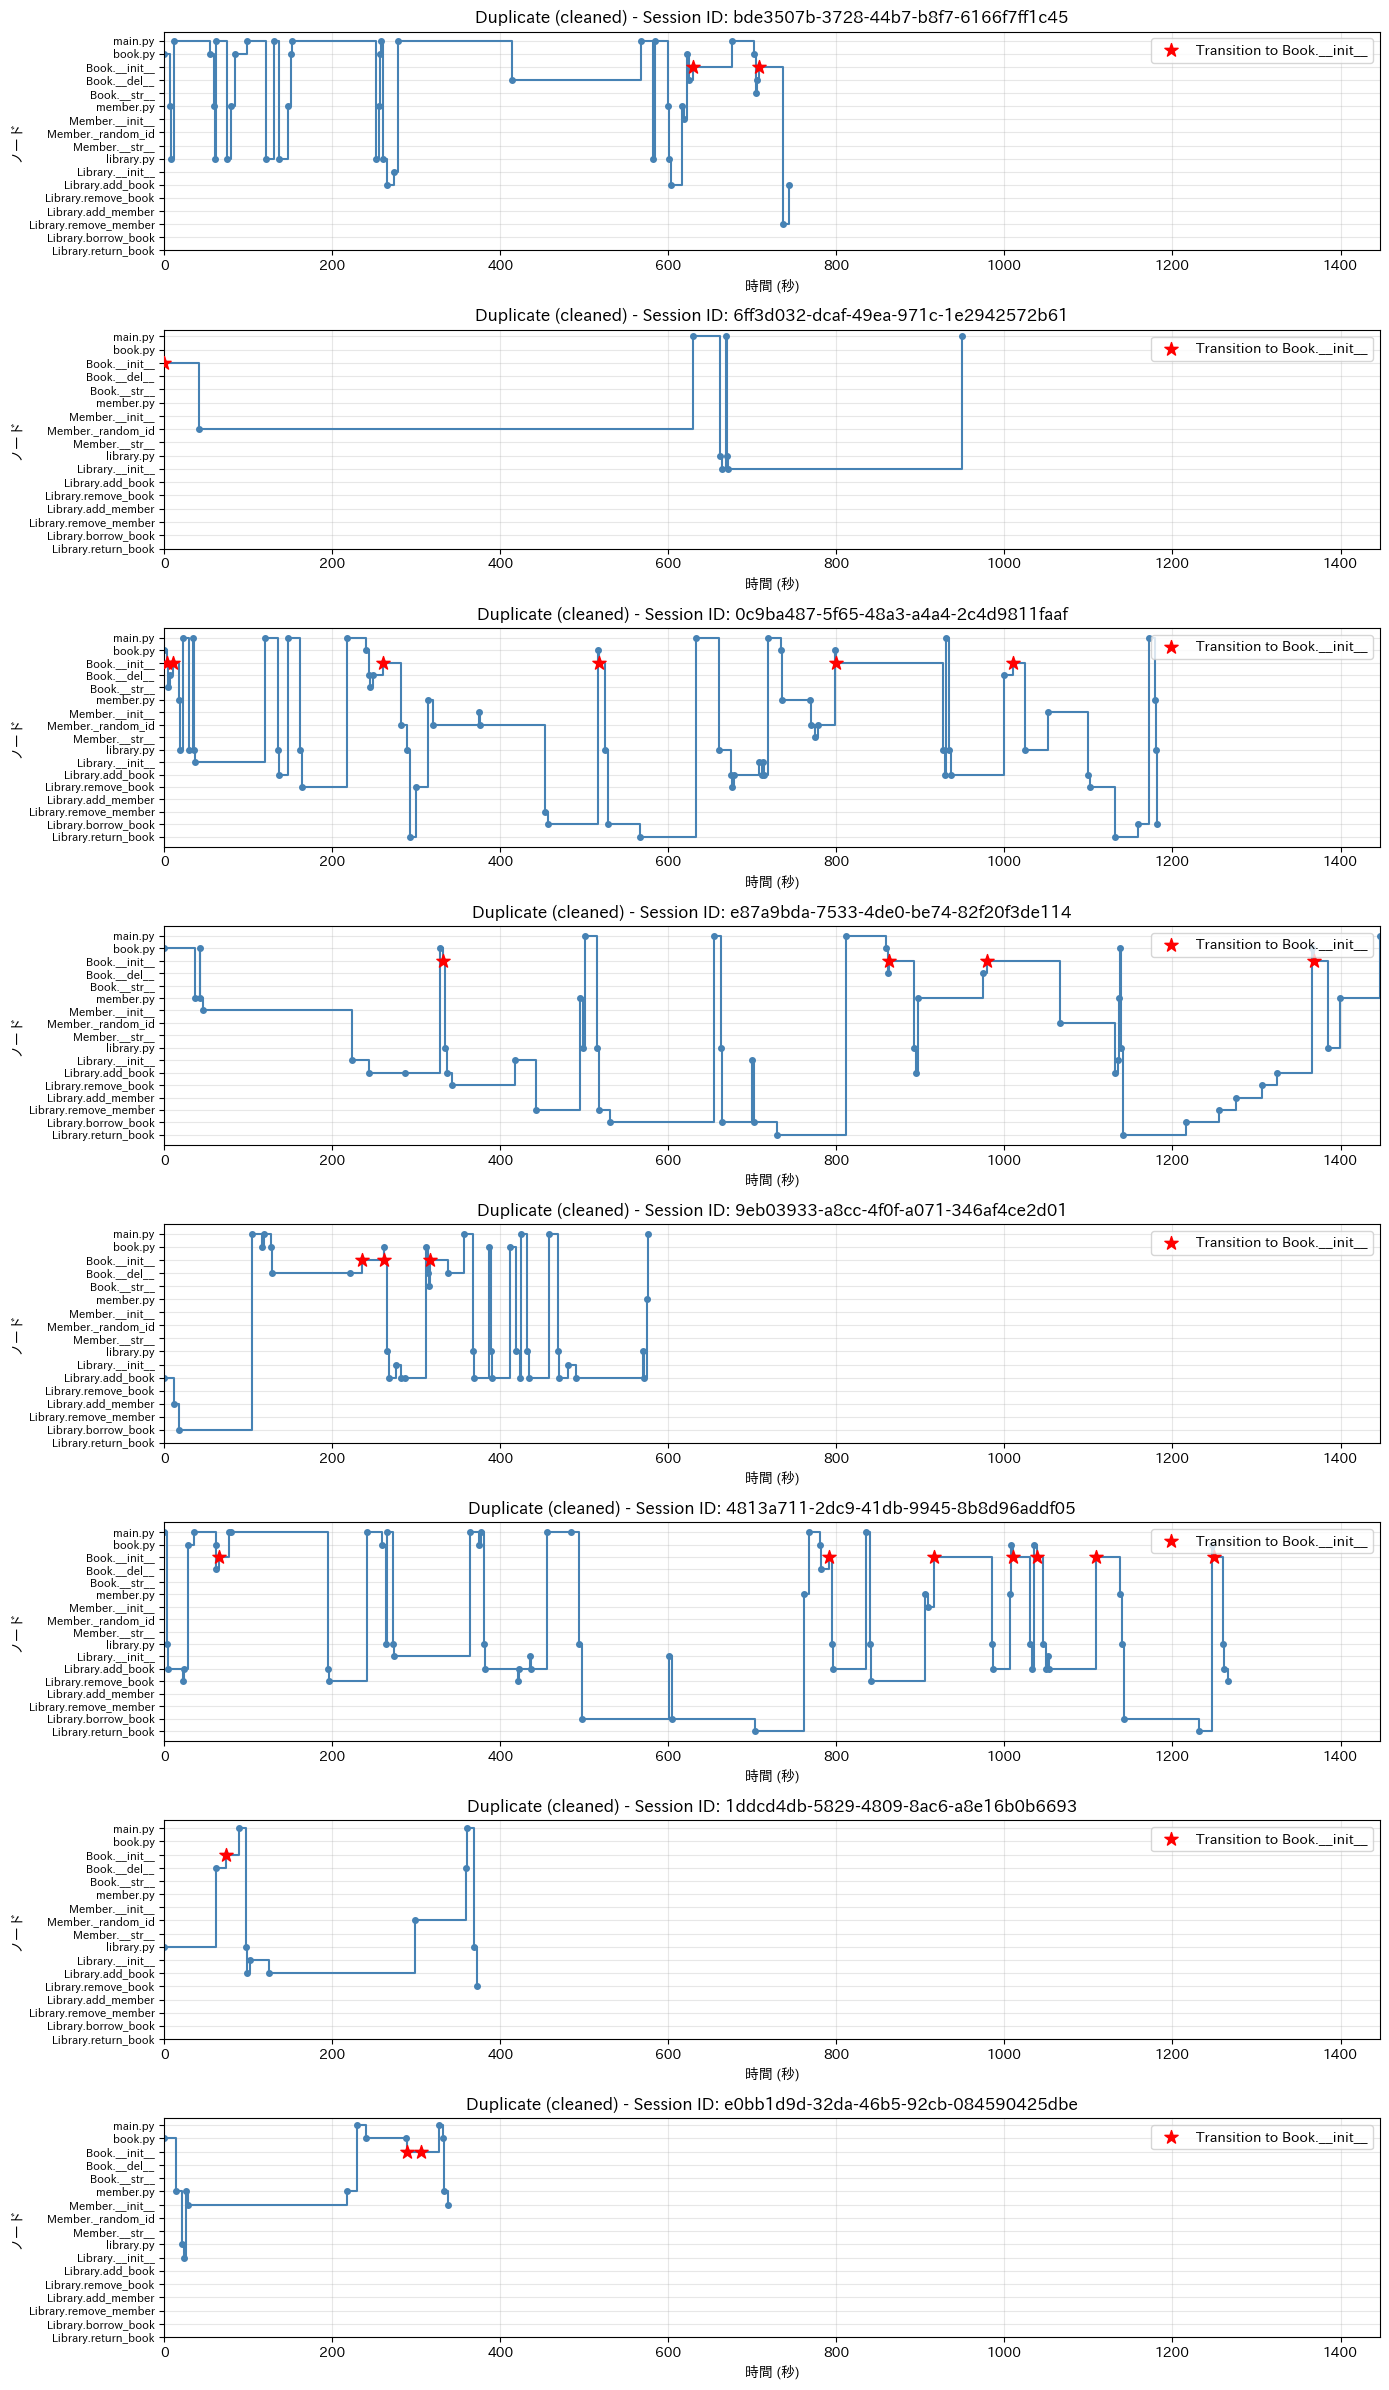

In [28]:
# 連続遷移を除去したデータで可視化
print("Exceed (cleaned) セッション数:", filtered_df_experiment_exceed_cleaned['session_id'].nunique())
print("Duplicate (cleaned) セッション数:", filtered_df_experiment_duplicate_cleaned['session_id'].nunique())

# Exceed cleaned 可視化
plot_task_transitions(
    filtered_df_experiment_exceed_cleaned,
    'Exceed (cleaned)',
    target_location='Library.borrow_book',
    n_sessions=7
)

# Duplicate cleaned 可視化
plot_task_transitions(
    filtered_df_experiment_duplicate_cleaned,
    'Duplicate (cleaned)',
    target_location='Book.__init__',
    n_sessions=8
)


## 平均訪問割合

In [33]:

def calculate_mean_probability(df):
    total_counts = df.sum(axis=0)

    # 場所ごとの割合
    probs = df.div(total_counts, axis=1)

    # 割合の重みづけ平均
    weights = total_counts / total_counts.sum()
    weighted_avg = (probs * weights).sum(axis=1)

    mean_dist = weighted_avg.to_frame(name='mean_probability')

    return mean_dist, probs

In [34]:
# 全ノードの割合、平均
mean_dist_exceed, probs_exceed = calculate_mean_probability(df_exceed)
mean_dist_duplicate, probs_duplicate = calculate_mean_probability(df_duplicate)

## 実験データ vs 定常分布（cosine）の比較

In [35]:
# CSVファイルから定常分布を読み込み
df_stationary_cosine_duplicate = pd.read_csv('../data/stationary_distribution_cosine_duplicate.csv', index_col='node')
df_stationary_cosine_exceed = pd.read_csv('../data/stationary_distribution_cosine_exceed.csv', index_col='node')
df_stationary_chunk_weighted = pd.read_csv('../data/stationary_distribution_chunk_weighted.csv', index_col='node')

# mean_dist と定常分布を結合（インデックスを統一）
all_nodes = set(mean_dist_duplicate.index) | set(df_stationary_cosine_duplicate.index) | set(df_stationary_chunk_weighted.index)
comparison_duplicate = pd.DataFrame({
    '実験データ (平均訪問割合)': mean_dist_duplicate.reindex(all_nodes, fill_value=0)['mean_probability'],
    '定常分布 (cosine)': df_stationary_cosine_duplicate.reindex(all_nodes, fill_value=0)['prob'],
    '定常分布 (chunk_weighted)': df_stationary_chunk_weighted.reindex(all_nodes, fill_value=0)['prob']
})

all_nodes_exceed = set(mean_dist_exceed.index) | set(df_stationary_cosine_exceed.index) | set(df_stationary_chunk_weighted.index)
comparison_exceed = pd.DataFrame({
    '実験データ (平均訪問割合)': mean_dist_exceed.reindex(all_nodes_exceed, fill_value=0)['mean_probability'],
    '定常分布 (cosine)': df_stationary_cosine_exceed.reindex(all_nodes_exceed, fill_value=0)['prob'],
    '定常分布 (chunk_weighted)': df_stationary_chunk_weighted.reindex(all_nodes_exceed, fill_value=0)['prob']
})

# topology_orderに従ってソート（存在しないノードは末尾に）
def sort_by_topology(df, topology_order):
    # topology_orderに含まれるノードとそうでないノードを分離
    in_topology = [node for node in topology_order if node in df.index]
    not_in_topology = [node for node in df.index if node not in topology_order]
    ordered_index = in_topology + not_in_topology
    return df.reindex(ordered_index)

comparison_duplicate_sorted = sort_by_topology(comparison_duplicate, topology_order)
comparison_exceed_sorted = sort_by_topology(comparison_exceed, topology_order)

print("Duplicate タスク:")
display(comparison_duplicate_sorted.head(10))

print("\nExceed タスク:")
display(comparison_exceed_sorted.head(10))


Duplicate タスク:


,実験データ (平均訪問割合),定常分布 (cosine),定常分布 (chunk_weighted)
main.py,0.134915,0.057,0.056
book.py,0.038657,0.216,0.037
Book.__init__,0.192361,0.130,0.127
Book.__del__,0.053288,0.009,0.049
Book.__str__,0.033575,0.059,0.063
member.py,0.018327,0.033,0.024
Member.__init__,0.022794,0.037,0.021
Member._random_id,0.032651,0.169,0.183
Member.__str__,0.016017,0.059,0.062
library.py,0.026182,0.034,0.018



Exceed タスク:


,実験データ (平均訪問割合),定常分布 (cosine),定常分布 (chunk_weighted)
main.py,0.216392,0.182,0.056
book.py,0.025197,0.097,0.037
Book.__init__,0.037104,0.009,0.127
Book.__del__,0.007476,0.009,0.049
Book.__str__,0.009137,0.059,0.063
member.py,0.030043,0.192,0.024
Member.__init__,0.034335,0.009,0.021
Member._random_id,0.057040,0.109,0.183
Member.__str__,0.008722,0.059,0.062
library.py,0.040565,0.058,0.018


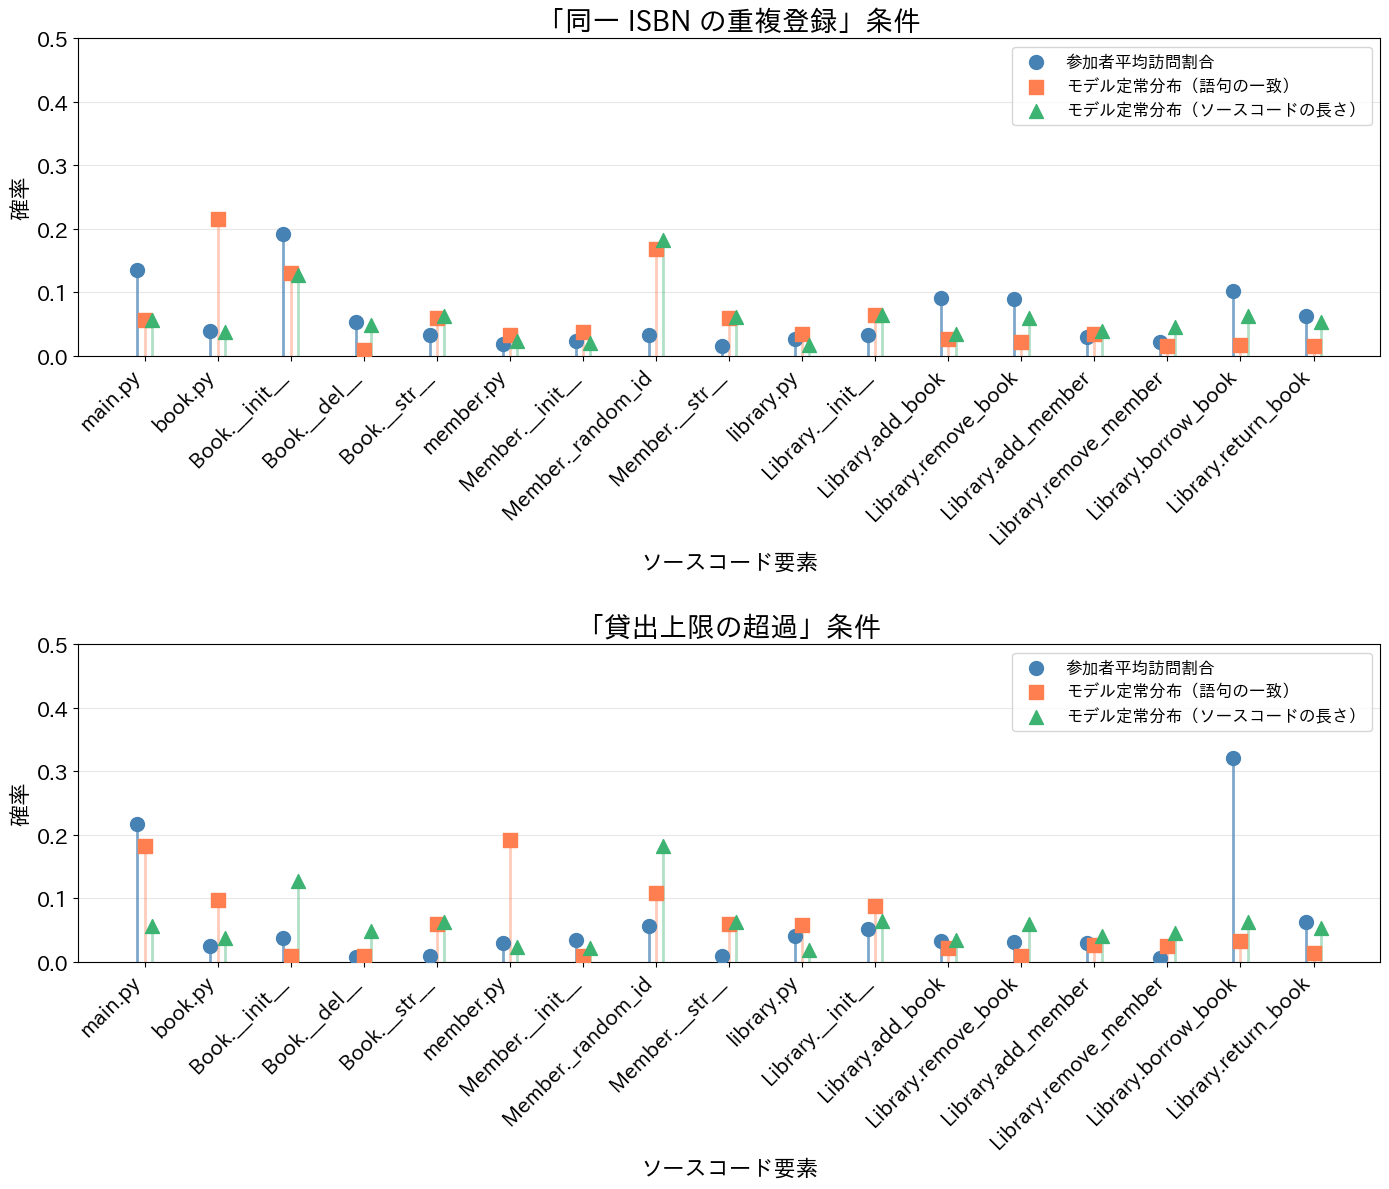

In [41]:
# ロリポップチャートでプロット（3系列）
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Duplicate タスクのプロット
ax1 = axes[0]
x_pos = range(len(comparison_duplicate_sorted))

# オフセット設定（重ならないように少しずらす）
offset = 0.1

# ロリポップチャート：実験データ（左側）
for i, (idx, row) in enumerate(comparison_duplicate_sorted.iterrows()):
    x_left = i - offset
    ax1.plot([x_left, x_left], [0, row['実験データ (平均訪問割合)']], color='steelblue', linewidth=2, alpha=0.7)
    ax1.scatter(x_left, row['実験データ (平均訪問割合)'], color='steelblue', s=100, marker='o', zorder=3, label='参加者平均訪問割合' if i == 0 else '')

# ロリポップチャート：定常分布 cosine（中央）
for i, (idx, row) in enumerate(comparison_duplicate_sorted.iterrows()):
    ax1.plot([i, i], [0, row['定常分布 (cosine)']], color='coral', linewidth=2, alpha=0.4)
    ax1.scatter(i, row['定常分布 (cosine)'], color='coral', s=100, marker='s', zorder=3, label='モデル定常分布（語句の一致）' if i == 0 else '')

# ロリポップチャート：定常分布 chunk_weighted（右側）
for i, (idx, row) in enumerate(comparison_duplicate_sorted.iterrows()):
    x_right = i + offset
    ax1.plot([x_right, x_right], [0, row['定常分布 (chunk_weighted)']], color='mediumseagreen', linewidth=2, alpha=0.4)
    ax1.scatter(x_right, row['定常分布 (chunk_weighted)'], color='mediumseagreen', s=100, marker='^', zorder=3, label='モデル定常分布（ソースコードの長さ）' if i == 0 else '')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(comparison_duplicate_sorted.index, rotation=45, ha='right', fontsize=15)
ax1.set_xlabel('ソースコード要素', fontsize=16)
ax1.set_ylabel('確率', fontsize=16)
ax1.set_title('「同一 ISBN の重複登録」条件', fontsize=20, fontweight='bold')
ax1.legend(loc='upper right', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, 0.5)
ax1.tick_params(axis='y', labelsize=15)

# Exceed タスクのプロット
ax2 = axes[1]
x_pos_exceed = range(len(comparison_exceed_sorted))

# ロリポップチャート：実験データ（左側）
for i, (idx, row) in enumerate(comparison_exceed_sorted.iterrows()):
    x_left = i - offset
    ax2.plot([x_left, x_left], [0, row['実験データ (平均訪問割合)']], color='steelblue', linewidth=2, alpha=0.7)
    ax2.scatter(x_left, row['実験データ (平均訪問割合)'], color='steelblue', s=100, marker='o', zorder=3, label='参加者平均訪問割合' if i == 0 else '')

# ロリポップチャート：定常分布 cosine（中央）
for i, (idx, row) in enumerate(comparison_exceed_sorted.iterrows()):
    ax2.plot([i, i], [0, row['定常分布 (cosine)']], color='coral', linewidth=2, alpha=0.4)
    ax2.scatter(i, row['定常分布 (cosine)'], color='coral', s=100, marker='s', zorder=3, label='モデル定常分布（語句の一致）' if i == 0 else '')

# ロリポップチャート：定常分布 chunk_weighted（右側）
for i, (idx, row) in enumerate(comparison_exceed_sorted.iterrows()):
    x_right = i + offset
    ax2.plot([x_right, x_right], [0, row['定常分布 (chunk_weighted)']], color='mediumseagreen', linewidth=2, alpha=0.4)
    ax2.scatter(x_right, row['定常分布 (chunk_weighted)'], color='mediumseagreen', s=100, marker='^', zorder=3, label='モデル定常分布（ソースコードの長さ）' if i == 0 else '')

ax2.set_xticks(x_pos_exceed)
ax2.set_xticklabels(comparison_exceed_sorted.index, rotation=45, ha='right', fontsize=15)
ax2.set_xlabel('ソースコード要素', fontsize=16)
ax2.set_ylabel('確率', fontsize=16)
ax2.set_title('「貸出上限の超過」条件', fontsize=20, fontweight='bold')
ax2.legend(loc='upper right', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, 0.5)
ax2.tick_params(axis='y', labelsize=15)

plt.tight_layout(h_pad=3)
plt.show()


## 可視化

In [31]:
from matplotlib.colors import PowerNorm

def plot_heatmap(df, title):
  plt.figure(figsize=(12, 8))
  # y軸をtopology_orderの順に並べ替える
  if 'topology_order' in globals():
    ordered_index = [loc for loc in topology_order if loc in df.index]
    df_to_plot = df.reindex(ordered_index) if ordered_index else df
  else:
    df_to_plot = df
  sns.heatmap(df_to_plot, annot=True, cmap='Oranges', fmt=".2f", linewidths=.5, 
              norm=PowerNorm(gamma=0.5, vmin=0, vmax=1))
  plt.title(title)
  plt.xlabel('参加者 ID')
  plt.ylabel('ソースコード要素')
  plt.xticks(rotation=45, ha='right')
  plt.yticks(rotation=0)
  plt.tight_layout()
  plt.show()

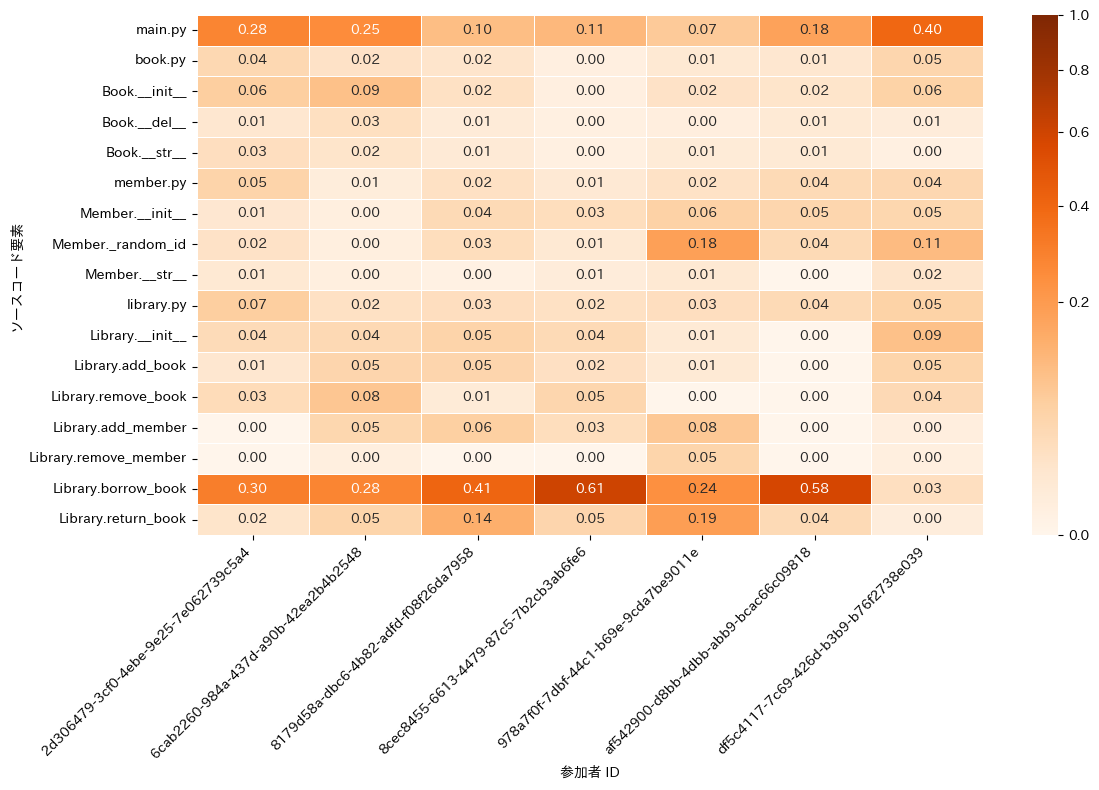

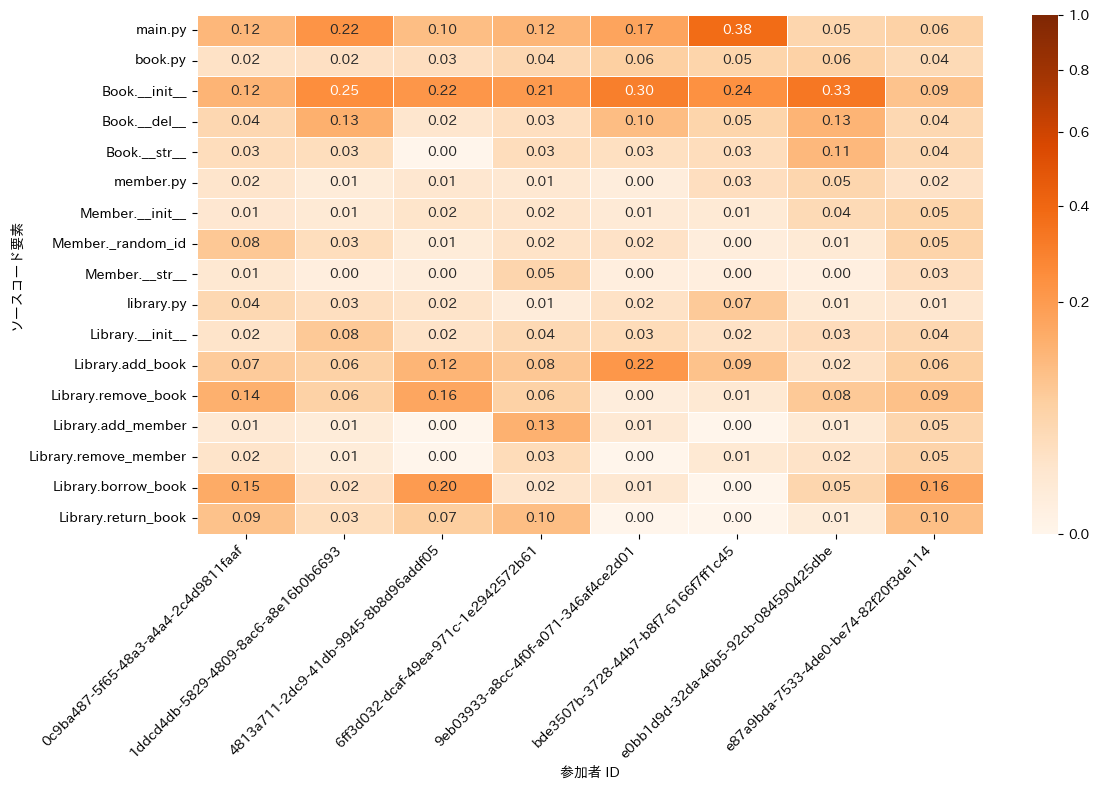

In [32]:
# Plot for 'exceed' task
plot_heatmap(probs_exceed, '')

# Plot for 'duplicate' task
plot_heatmap(probs_duplicate, '')

### 連続遷移除去後の平均訪問割合 (ヒートマップ)

In [33]:
# 連続遷移を除去したデータで平均訪問割合を計算
df_exceed_cleaned = filtered_df_experiment_exceed_cleaned.groupby(['session_id', 'location'])['stay_time'].sum().unstack(fill_value=0).T
df_duplicate_cleaned = filtered_df_experiment_duplicate_cleaned.groupby(['session_id', 'location'])['stay_time'].sum().unstack(fill_value=0).T

if df_exceed_cleaned.empty:
    print("Exceed (cleaned): データなし")
else:
    mean_dist_exceed_cleaned, probs_exceed_cleaned = calculate_mean_probability(df_exceed_cleaned)
    print("Exceed (cleaned) 平均訪問割合:")
    display(mean_dist_exceed_cleaned)

if df_duplicate_cleaned.empty:
    print("Duplicate (cleaned): データなし")
else:
    mean_dist_duplicate_cleaned, probs_duplicate_cleaned = calculate_mean_probability(df_duplicate_cleaned)
    print("Duplicate (cleaned) 平均訪問割合:")
    display(mean_dist_duplicate_cleaned)

Exceed (cleaned) 平均訪問割合:


,mean_probability
location,
Book.__del__,0.003501
Book.__init__,0.020340
Book.__str__,0.005335
Library.__init__,0.034512
Library.add_book,0.017839
Library.add_member,0.030010
Library.borrow_book,0.385295
Library.remove_book,0.016005
Library.remove_member,0.005669


Duplicate (cleaned) 平均訪問割合:


,mean_probability
location,
Book.__del__,0.032007
Book.__init__,0.112745
Book.__str__,0.002307
Library.__init__,0.035755
Library.add_book,0.107843
Library.add_member,0.009804
Library.borrow_book,0.175894
Library.remove_book,0.077855
Library.remove_member,0.022203


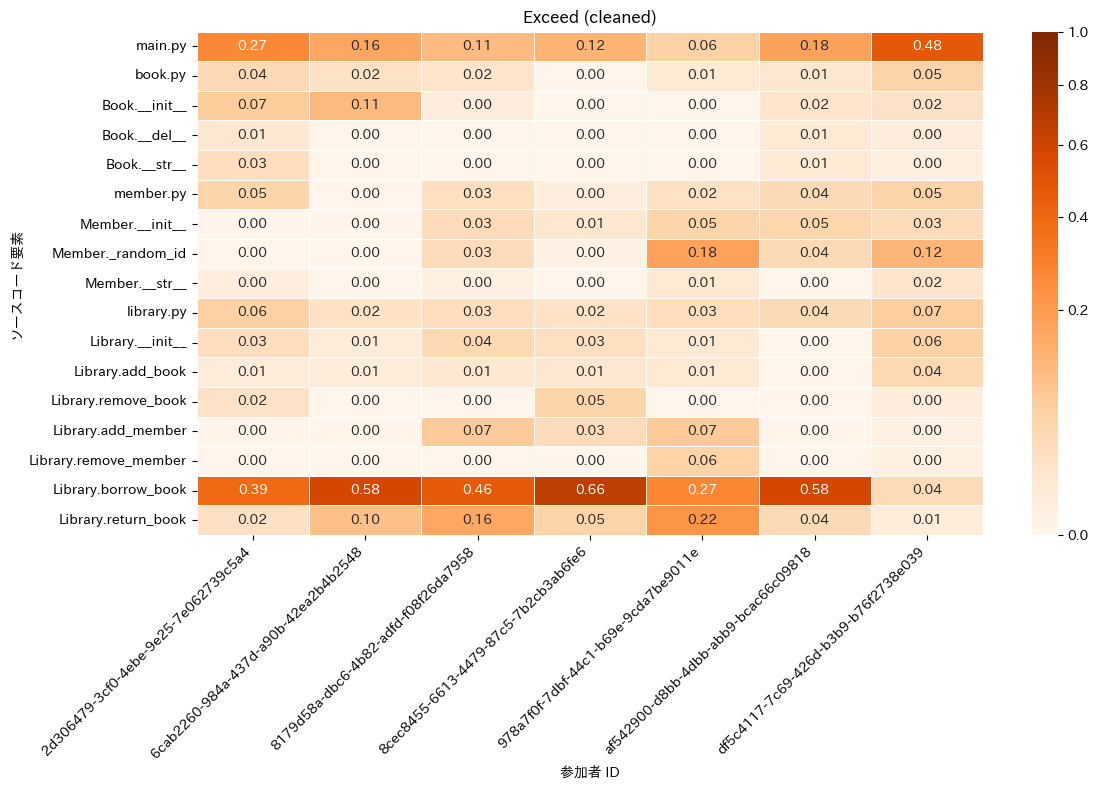

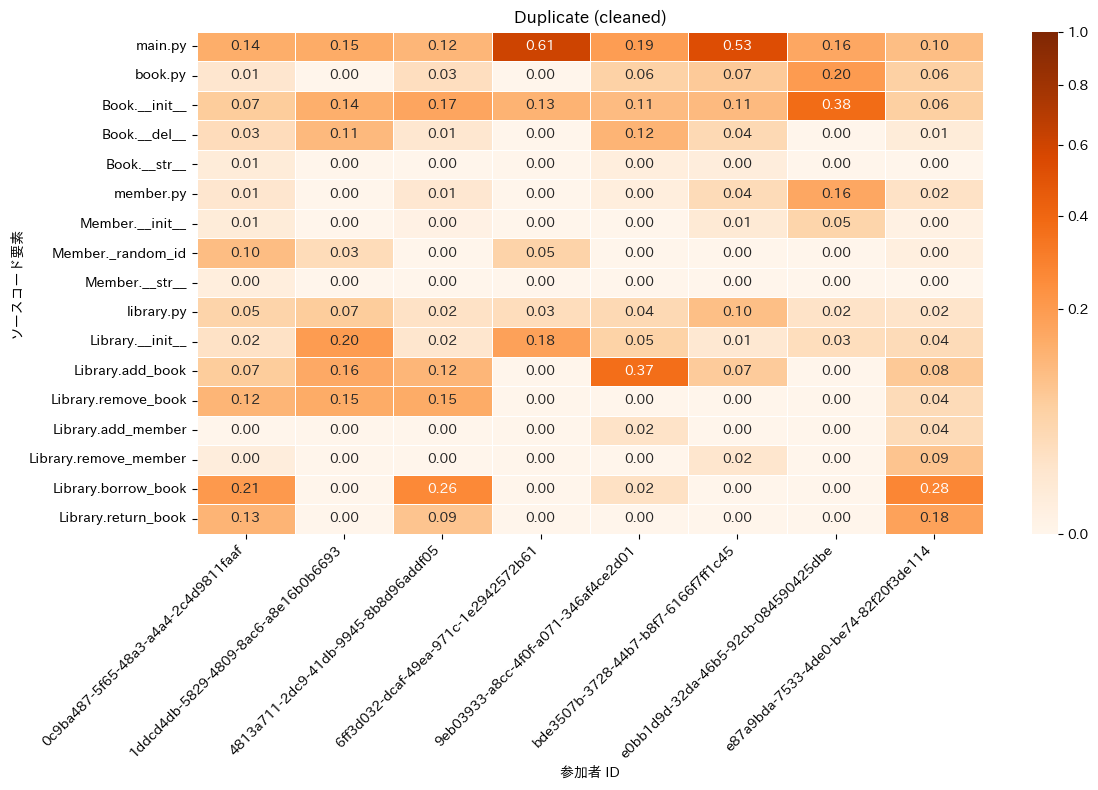

In [34]:
# cleanedデータの平均訪問割合をヒートマップで可視化
if not df_exceed_cleaned.empty:
    plot_heatmap(probs_exceed_cleaned, 'Exceed (cleaned)')
if not df_duplicate_cleaned.empty:
    plot_heatmap(probs_duplicate_cleaned, 'Duplicate (cleaned)')

In [35]:
# cleaned平均訪問割合をCSVとして保存
if 'mean_dist_exceed_cleaned' in globals():
    mean_dist_exceed_cleaned.to_csv('../data/mean_probability_exceed_cleaned.csv')
    print('Exceed (cleaned) を保存しました: ../data/mean_probability_exceed_cleaned.csv')
else:
    print('Exceed (cleaned) の平均訪問割合が未計算です')

if 'mean_dist_duplicate_cleaned' in globals():
    mean_dist_duplicate_cleaned.to_csv('../data/mean_probability_duplicate_cleaned.csv')
    print('Duplicate (cleaned) を保存しました: ../data/mean_probability_duplicate_cleaned.csv')
else:
    print('Duplicate (cleaned) の平均訪問割合が未計算です')

Exceed (cleaned) を保存しました: ../data/mean_probability_exceed_cleaned.csv
Duplicate (cleaned) を保存しました: ../data/mean_probability_duplicate_cleaned.csv


# 回答の正誤ごとに分析

## データ前処理

In [24]:
# stay_time が 4秒以上の行のみを使用
filtered_df_experiment_events = df_experiment_trimmed[
    (df_experiment_trimmed['event_type'].isin(['method', 'file'])) 
    # & (df_experiment_trimmed['stay_time'] >= 4)
]

df_exceed_correct_true = filtered_df_experiment_events[
    (filtered_df_experiment_events['task'] == 'exceed') &
    (filtered_df_experiment_events['correct'] == True)
].groupby(['session_id', 'location'])['stay_time'].sum().unstack(fill_value=0).T

df_duplicate_correct_true = filtered_df_experiment_events[
    (filtered_df_experiment_events['task'] == 'duplicate') &
    (filtered_df_experiment_events['correct'] == True)
].groupby(['session_id', 'location'])['stay_time'].sum().unstack(fill_value=0).T

df_exceed_correct_false = filtered_df_experiment_events[
    (filtered_df_experiment_events['task'] == 'exceed') &
    (filtered_df_experiment_events['correct'] == False)
].groupby(['session_id', 'location'])['stay_time'].sum().unstack(fill_value=0).T

df_duplicate_correct_false = filtered_df_experiment_events[
    (filtered_df_experiment_events['task'] == 'duplicate') &
    (filtered_df_experiment_events['correct'] == False)
].groupby(['session_id', 'location'])['stay_time'].sum().unstack(fill_value=0).T

## 平均訪問割合

In [27]:
mean_dist_exceed_correct_true, probs_exceed_correct_true = calculate_mean_probability(df_exceed_correct_true)
mean_dist_duplicate_correct_true, probs_duplicate_correct_true = calculate_mean_probability(df_duplicate_correct_true)
mean_dist_exceed_correct_false, probs_exceed_correct_false = calculate_mean_probability(df_exceed_correct_false)
mean_dist_duplicate_correct_false, probs_duplicate_correct_false = calculate_mean_probability(df_duplicate_correct_false)

## 可視化


In [30]:
from matplotlib.colors import PowerNorm

def plot_heatmap_on_ax(ax, df, title, show_ylabel=True, show_cbar=True, highlight_ylabel=None):
    if df.empty:
        ax.text(0.5, 0.5, 'No data to display', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=12, color='gray')
        ax.set_title(title, fontsize=16, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])
    else:
        # topology_orderに基づいてDataFrameの行を並べ替え
        if 'topology_order' in globals():
            # topology_orderに存在する行を順序通りに並べる
            ordered_rows = [row for row in topology_order if row in df.index]
            # topology_orderに存在しない行を末尾に追加
            remaining_rows = [row for row in df.index if row not in topology_order]
            df = df.reindex(ordered_rows + remaining_rows)
        
        sns.heatmap(
            df,
            annot=True,
            cmap='Oranges',
            fmt=".2f",
            linewidths=.5,
            norm=PowerNorm(gamma=0.5, vmin=0, vmax=1),
            ax=ax,
            cbar=show_cbar,
            annot_kws={"fontsize": 12}
        )
        ax.set_title(title, fontsize=16, fontweight='bold')
        ax.set_xlabel('')

        if show_ylabel:
            ax.set_ylabel('ソースコード要素', fontsize=16)
        else:
            ax.set_ylabel('')
        # session_id を先頭3文字で表示
        xtick_labels = [str(t.get_text())[:3] for t in ax.get_xticklabels()]
        ax.set_xticklabels(xtick_labels, rotation=0, ha='center', fontsize=15)
        if show_ylabel:
            yticklabels = ax.get_yticklabels()
            ax.set_yticklabels(yticklabels, rotation=0, fontsize=15)
            # 特定のラベルを赤色でハイライト
            if highlight_ylabel:
                for label in yticklabels:
                    if label.get_text() == highlight_ylabel:
                        label.set_color('red')
        else:
            ax.set_yticklabels([])
        if show_cbar and ax.collections:
            cbar = ax.collections[0].colorbar
            if cbar is not None:
                cbar.ax.tick_params(labelsize=15)


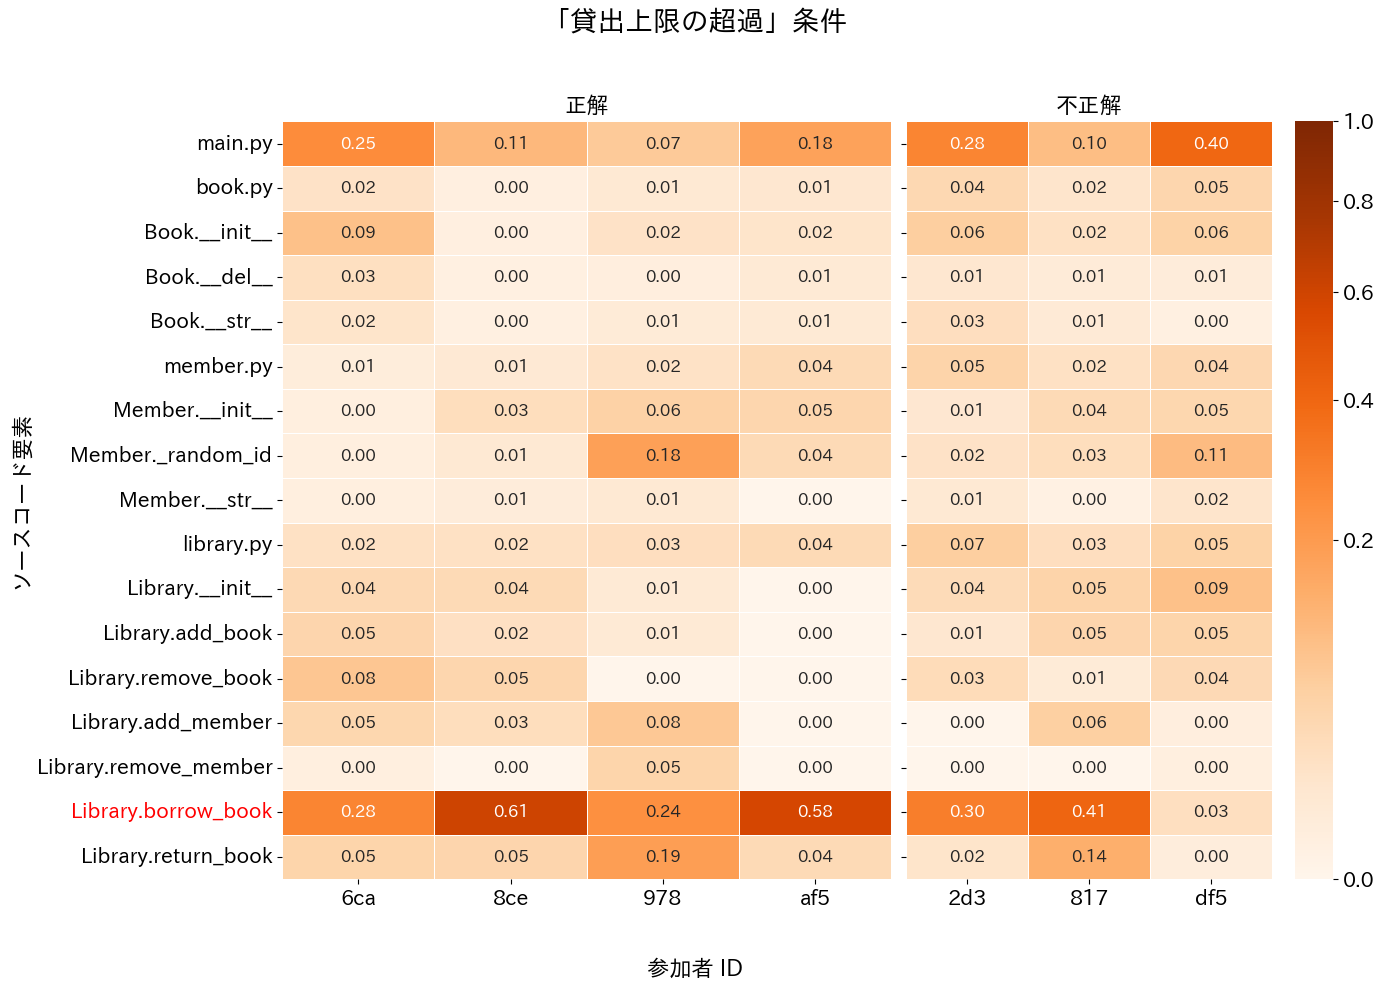

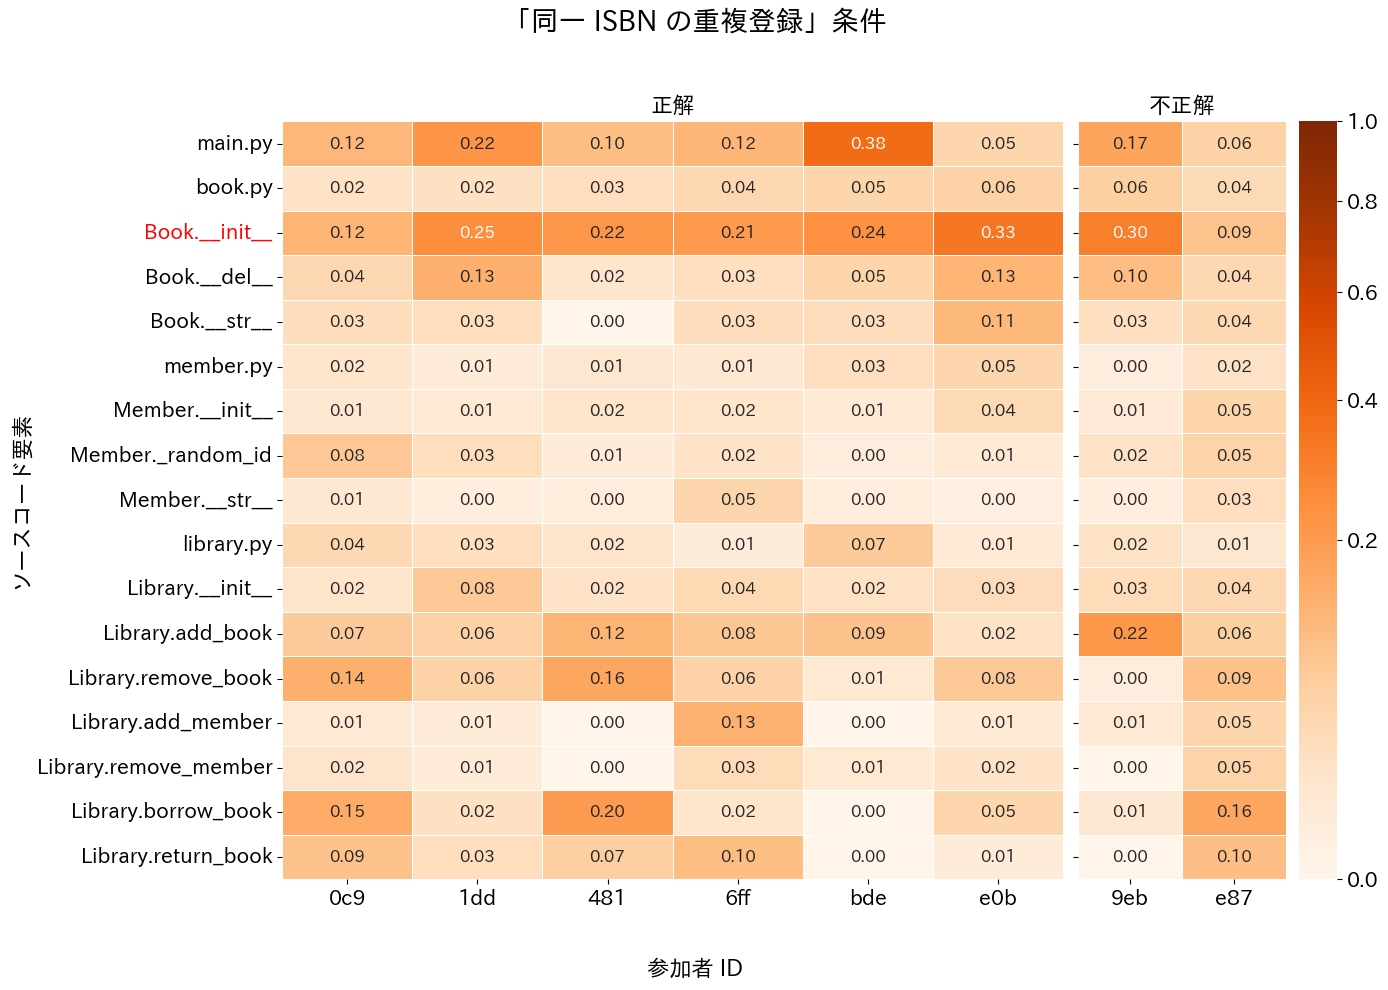

In [31]:
# exceed
# データ数に応じて幅の比率を計算
n_true_exceed = probs_exceed_correct_true.shape[1]
n_false_exceed = probs_exceed_correct_false.shape[1]
# width_ratios_exceed = [n_true_exceed, n_false_exceed]
width_ratios_exceed = [4, 3]

task_labels = {
    'duplicate': '「同一 ISBN の重複登録」条件',
    'exceed': '「貸出上限の超過」条件'
}

fig_exceed, axes_exceed = plt.subplots(1, 2, figsize=(14, 10), gridspec_kw={'width_ratios': width_ratios_exceed})
plot_heatmap_on_ax(axes_exceed[0], probs_exceed_correct_true, '正解', show_ylabel=True, show_cbar=False, highlight_ylabel='Library.borrow_book')
plot_heatmap_on_ax(axes_exceed[1], probs_exceed_correct_false, '不正解', show_ylabel=False, show_cbar=True)
fig_exceed.suptitle(task_labels['exceed'], fontsize=20, fontweight='bold')
fig_exceed.supxlabel('参加者 ID', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Create a figure and two subplots for the 'duplicate' task
# データ数に応じて幅の比率を計算
n_true_duplicate = probs_duplicate_correct_true.shape[1]
n_false_duplicate = probs_duplicate_correct_false.shape[1]
width_ratios_duplicate = [n_true_duplicate, n_false_duplicate]

fig_duplicate, axes_duplicate = plt.subplots(1, 2, figsize=(14, 10), gridspec_kw={'width_ratios': width_ratios_duplicate})
plot_heatmap_on_ax(axes_duplicate[0], probs_duplicate_correct_true, '正解', show_ylabel=True, show_cbar=False, highlight_ylabel='Book.__init__')
plot_heatmap_on_ax(axes_duplicate[1], probs_duplicate_correct_false, '不正解', show_ylabel=False, show_cbar=True)
fig_duplicate.suptitle(task_labels['duplicate'], fontsize=20, fontweight='bold')
fig_duplicate.supxlabel('参加者 ID', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



# 平均訪問割合をCSVとして保存

In [ ]:
# 平均訪問割合をローカルに保存（stay_time >= 4秒）
# 保存先: ../data/

mean_dist_duplicate.to_csv('../data/mean_probability_duplicate_stay4s.csv')
mean_dist_exceed.to_csv('../data/mean_probability_exceed_stay4s.csv')

print("全データの平均訪問割合を保存しました (stay_time >= 4s):")
print("- mean_probability_duplicate_stay4s.csv")
print("- mean_probability_exceed_stay4s.csv")

# 正誤ごとの平均訪問割合（stay_time >= 4秒）
mean_dist_duplicate_correct_true.to_csv('../data/mean_probability_duplicate_correct_true_stay4s.csv')
mean_dist_duplicate_correct_false.to_csv('../data/mean_probability_duplicate_correct_false_stay4s.csv')
mean_dist_exceed_correct_true.to_csv('../data/mean_probability_exceed_correct_true_stay4s.csv')
mean_dist_exceed_correct_false.to_csv('../data/mean_probability_exceed_correct_false_stay4s.csv')

print("\n正誤ごとの平均訪問割合を保存しました (stay_time >= 4s):")
print("- mean_probability_duplicate_correct_true_stay4s.csv")
print("- mean_probability_duplicate_correct_false_stay4s.csv")
print("- mean_probability_exceed_correct_true_stay4s.csv")
print("- mean_probability_exceed_correct_false_stay4s.csv")


全データの平均訪問割合を保存しました (stay_time >= 4s):
- mean_probability_duplicate_stay4s.csv
- mean_probability_exceed_stay4s.csv

正誤ごとの平均訪問割合を保存しました (stay_time >= 4s):
- mean_probability_duplicate_correct_true_stay4s.csv
- mean_probability_duplicate_correct_false_stay4s.csv
- mean_probability_exceed_correct_true_stay4s.csv
- mean_probability_exceed_correct_false_stay4s.csv


## セッション前半/後半の分析
セッション内の滞在時間を累積し、各セッションの合計滞在時間を二分（前半・後半）して、locationごとの訪問割合のヒートマップを表示します。

In [52]:
# セッションごとの滞在時間の前半/後半を付与
df_exp_sorted = df_experiment.sort_values(['session_id', 'occurred_at_jst']).copy()
total_per_session = df_exp_sorted.groupby('session_id')['stay_time'].sum()
half_map = (total_per_session / 2)
df_exp_sorted['cum_stay_time'] = df_exp_sorted.groupby('session_id')['stay_time'].cumsum()

# 境界を跨ぐ行の部分時間は考慮せず、行単位で前半/後半に割当て
df_exp_sorted['time_half'] = df_exp_sorted.apply(
    lambda row: 'first_half' if row['cum_stay_time'] <= half_map.loc[row['session_id']] else 'second_half',
    axis=1
)

# イベントタイプで絞り込み（method/file のみ）
df_exp_events = df_exp_sorted[df_exp_sorted['event_type'].isin(['method', 'file'])]

In [53]:
# 前半/後半の行を集計して、location×session の行列を作成
def build_half_matrix(df_half):
    return df_half.groupby(['session_id', 'location'])['stay_time'].sum().unstack(fill_value=0).T

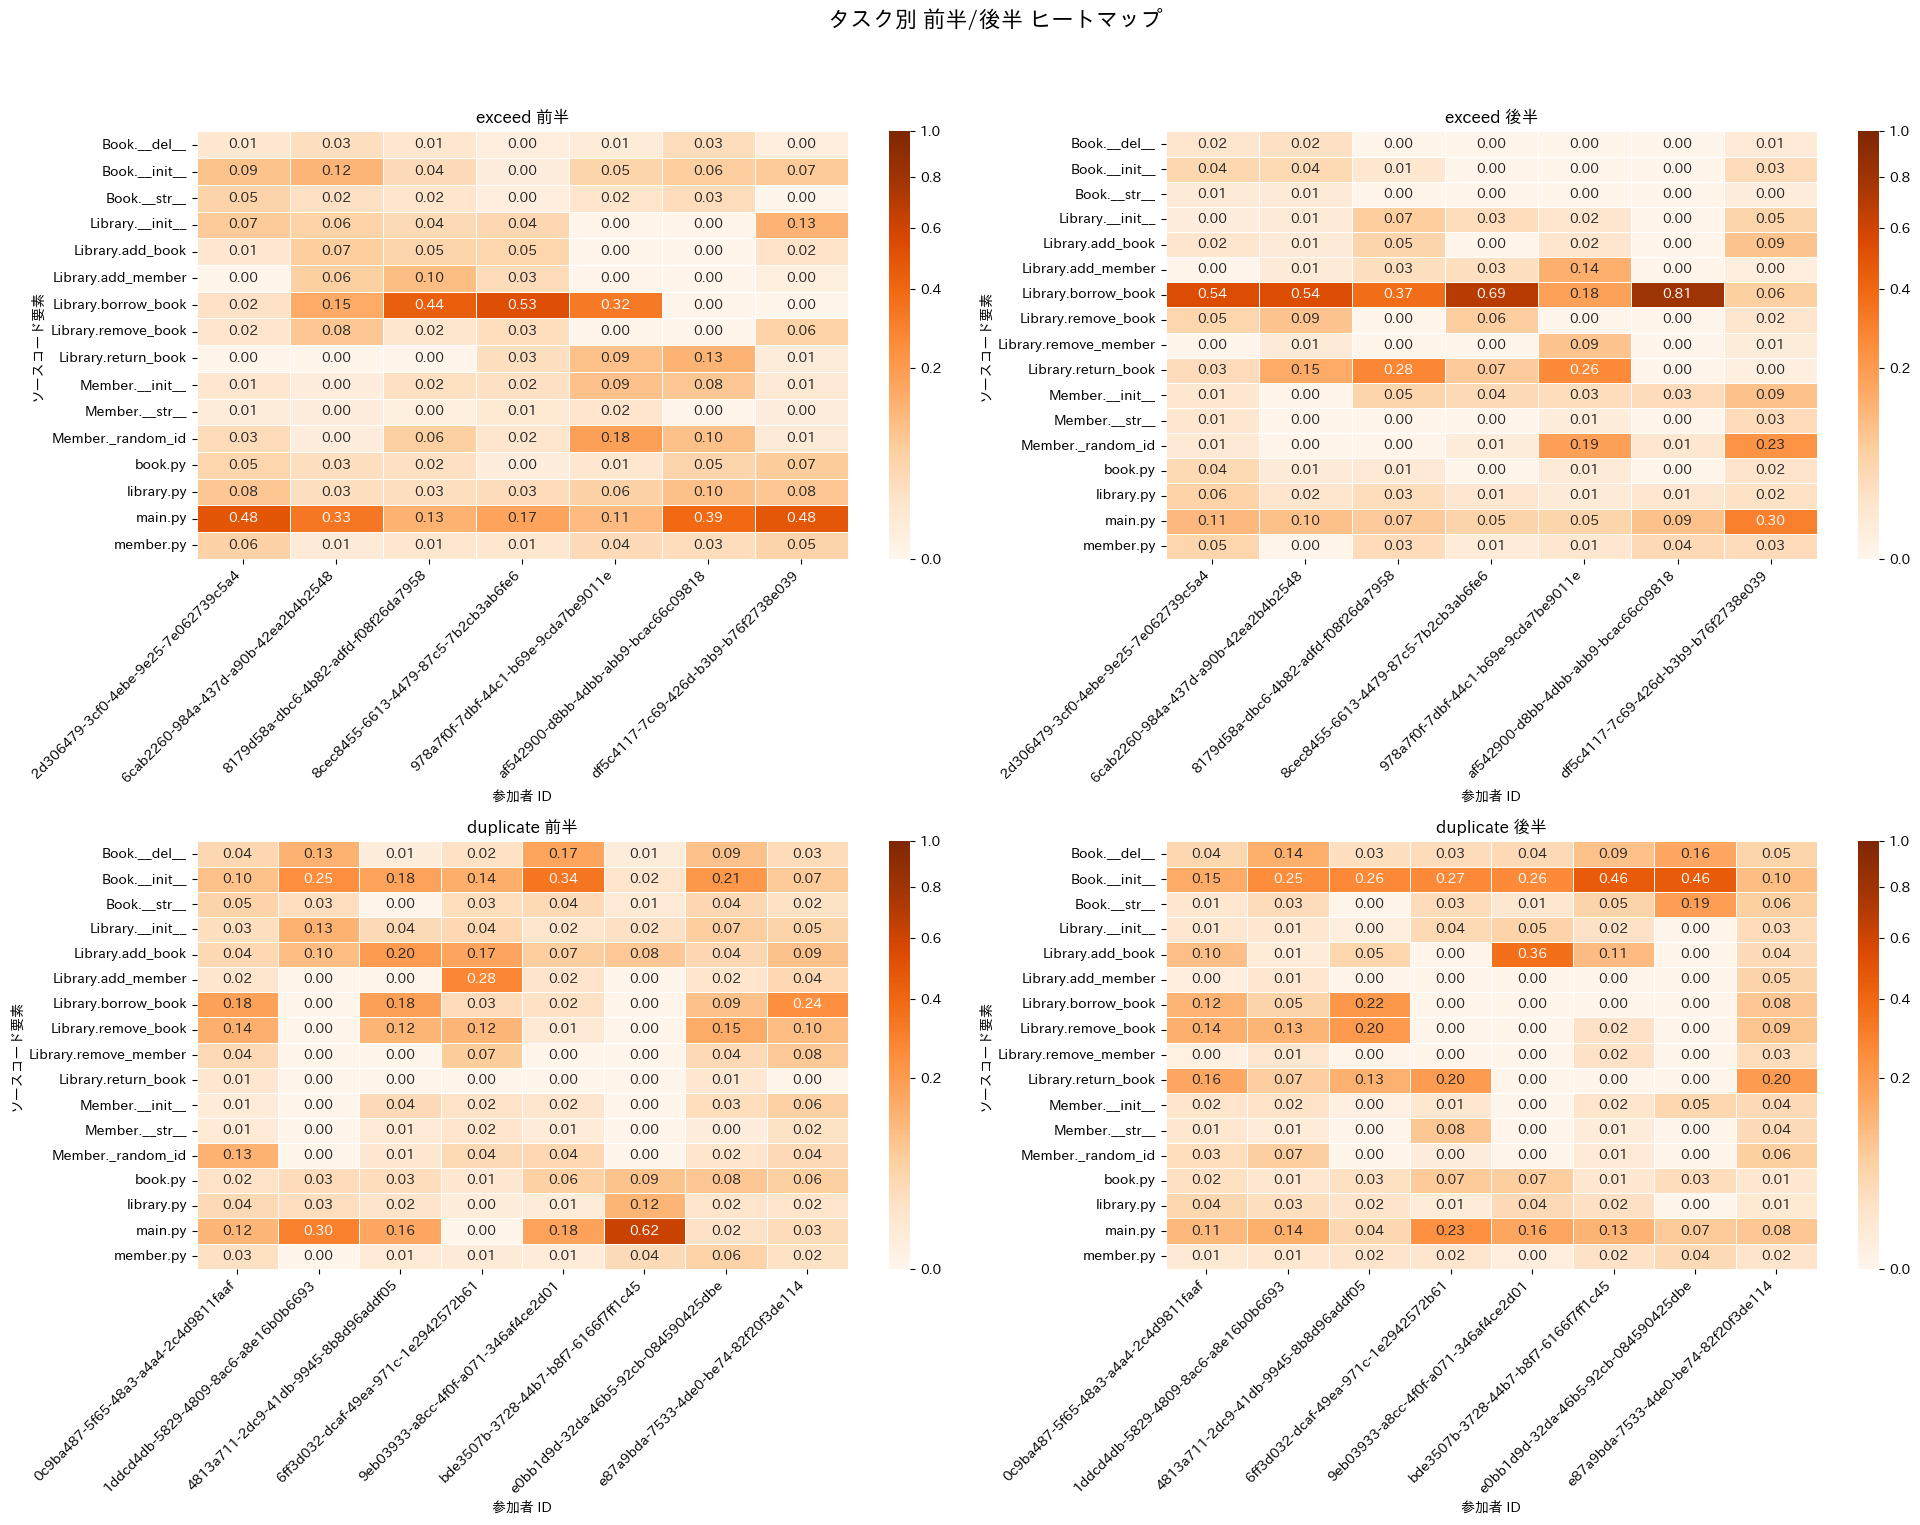

In [57]:
# タスク別の前半/後半ヒートマップ
df_first_exceed = build_half_matrix(df_exp_events[(df_exp_events['time_half']=='first_half') & (df_exp_events['task']=='exceed')])
df_second_exceed = build_half_matrix(df_exp_events[(df_exp_events['time_half']=='second_half') & (df_exp_events['task']=='exceed')])

df_first_duplicate = build_half_matrix(df_exp_events[(df_exp_events['time_half']=='first_half') & (df_exp_events['task']=='duplicate')])
df_second_duplicate = build_half_matrix(df_exp_events[(df_exp_events['time_half']=='second_half') & (df_exp_events['task']=='duplicate')])

mean_first_exceed, probs_first_exceed = calculate_mean_probability(df_first_exceed)
mean_second_exceed, probs_second_exceed = calculate_mean_probability(df_second_exceed)
mean_first_duplicate, probs_first_duplicate = calculate_mean_probability(df_first_duplicate)
mean_second_duplicate, probs_second_duplicate = calculate_mean_probability(df_second_duplicate)

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
plot_heatmap_on_ax(axes[0,0], probs_first_exceed, 'exceed 前半')
plot_heatmap_on_ax(axes[0,1], probs_second_exceed, 'exceed 後半')
plot_heatmap_on_ax(axes[1,0], probs_first_duplicate, 'duplicate 前半')
plot_heatmap_on_ax(axes[1,1], probs_second_duplicate, 'duplicate 後半')
fig.suptitle('タスク別 前半/後半 ヒートマップ', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
mean_first_duplicate.to_csv('../data/mean_probability_duplicate_first.csv')
mean_second_duplicate.to_csv('../data/mean_probability_duplicate_second.csv')
mean_first_exceed.to_csv('../data/mean_probability_exceed_first.csv')
mean_second_exceed.to_csv('../data/mean_probability_exceed_second.csv')

## 最後の main.py から終了までの遷移ログ

In [ ]:
# duplicate/exceed のイベントから、最後の main.py（セッション終端が main.py の場合は直前の main.py）以降の遷移ログを抽出
# 前提: filtered_df_experiment_duplicate / filtered_df_experiment_exceed が存在し、'occurred_at_jst' が時系列を表す

# duplicate と exceed を結合（イベント粒度）
_df_union = (
    pd.concat([filtered_df_experiment_duplicate, filtered_df_experiment_exceed], ignore_index=True)
    .sort_values(['session_id', 'occurred_at_jst'])
)

# セッション内の順序付け
_df_sorted = _df_union.assign(row_in_session=lambda d: d.groupby('session_id').cumcount())

# 各セッションで 'main.py' が最後に現れる行番号（row_in_session）
_last_main_row = (
    _df_sorted[_df_sorted['location'] == 'main.py']
    .groupby('session_id')['row_in_session']
    .max()
)

# 各セッションの最後の location（duplicate/exceedイベント内での終端）
_last_location = _df_sorted.groupby('session_id')['location'].last()

# 各セッションで 'main.py' の直前（2番目に最後）の行番号（存在する場合）
_main_rows = _df_sorted[_df_sorted['location'] == 'main.py'][['session_id', 'row_in_session']]
_second_last_main_row = (
    _main_rows.groupby('session_id')['row_in_session']
    .apply(lambda s: s.iloc[-2] if len(s) >= 2 else np.nan)
)

# 抽出開始行番号を決定
# セッション終端が 'main.py' の場合、可能なら直前（2番目に最後）の 'main.py' から開始
# それ以外は最後の 'main.py' から開始
_end_is_main = _last_location.eq('main.py')
_df_sorted['start_main_row'] = np.where(
    _df_sorted['session_id'].map(_end_is_main) & _df_sorted['session_id'].map(_second_last_main_row).notna(),
    _df_sorted['session_id'].map(_second_last_main_row),
    _df_sorted['session_id'].map(_last_main_row)
)

# しきい値（開始の main.py の行番号）以降の行のみを残す（しきい値行を含む）
df_post_main_logs = (
    _df_sorted[
        _df_sorted['start_main_row'].notna() &
        (_df_sorted['row_in_session'] >= _df_sorted['start_main_row'])
    ]
    .drop(columns=['row_in_session', 'start_main_row'])
    .sort_values(['session_id', 'occurred_at_jst'])
    .copy()
)

# 遷移の確認用に直前 location を付与（同一セッション内）
df_post_main_logs['prev_location'] = df_post_main_logs.groupby('session_id')['location'].shift(1)

# 統計表示
sessions_end_main = set(_last_location[_last_location == 'main.py'].index)
sessions_with_second_last = set(_second_last_main_row.dropna().index)
adjusted_sessions = len(sessions_end_main & sessions_with_second_last)

print(f"対象セッション数: {df_post_main_logs['session_id'].nunique()}")
print(f"抽出行数: {len(df_post_main_logs):,}")
print(f"最後が main.py のセッションで直前 main.py から抽出に切替: {adjusted_sessions}")

display(df_post_main_logs.head(20))

# 必要に応じて保存する場合は以下を有効化
# df_post_main_logs.to_csv('../data/post_main_transition_logs_from_union.csv', index=False)


対象セッション数: 15
抽出行数: 210
最後が main.py のセッションで直前 main.py から抽出に切替: 4


,session_id,event_type,location,occurred_at_jst,task,correct,updated_at,stay_time,prev_location
120,0c9ba487-5f65-48a3-a4a4-2c4d9811faaf,file,main.py,2025-12-15 11:01:58,duplicate,True,2025-12-15 11:03:05,7.0,NaN
121,0c9ba487-5f65-48a3-a4a4-2c4d9811faaf,file,member.py,2025-12-15 11:02:05,duplicate,True,2025-12-15 11:03:05,1.0,main.py
122,0c9ba487-5f65-48a3-a4a4-2c4d9811faaf,file,library.py,2025-12-15 11:02:06,duplicate,True,2025-12-15 11:03:05,2.0,member.py
123,0c9ba487-5f65-48a3-a4a4-2c4d9811faaf,method,Library.borrow_book,2025-12-15 11:02:08,duplicate,True,2025-12-15 11:03:05,57.0,library.py
155,1ddcd4db-5829-4809-8ac6-a8e16b0b6693,file,main.py,2025-12-22 10:42:36,duplicate,True,2025-12-22 10:43:05,9.0,NaN
156,1ddcd4db-5829-4809-8ac6-a8e16b0b6693,file,library.py,2025-12-22 10:42:45,duplicate,True,2025-12-22 10:43:05,3.0,main.py
157,1ddcd4db-5829-4809-8ac6-a8e16b0b6693,method,Library.remove_book,2025-12-22 10:42:48,duplicate,True,2025-12-22 10:43:05,17.0,library.py
648,2d306479-3cf0-4ebe-9e25-7e062739c5a4,file,main.py,2025-12-15 16:41:22,exceed,False,2025-12-15 16:42:45,6.0,NaN
649,2d306479-3cf0-4ebe-9e25-7e062739c5a4,file,member.py,2025-12-15 16:41:28,exceed,False,2025-12-15 16:42:45,3.0,main.py
650,2d306479-3cf0-4ebe-9e25-7e062739c5a4,file,book.py,2025-12-15 16:41:31,exceed,False,2025-12-15 16:42:45,2.0,member.py


## df_post_main_logs の可視化（タスク別）

Duplicate タスク: 133 行、セッション数: 8
Exceed タスク: 77 行、セッション数: 7
Duplicate (post-main) タスクの総セッション数: 8


/var/folders/ry/b358j0pn36g39t8rbntyw_lr0000gn/T/ipykernel_66293/3832293611.py:110: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')
/var/folders/ry/b358j0pn36g39t8rbntyw_lr0000gn/T/ipykernel_66293/3832293611.py:110: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


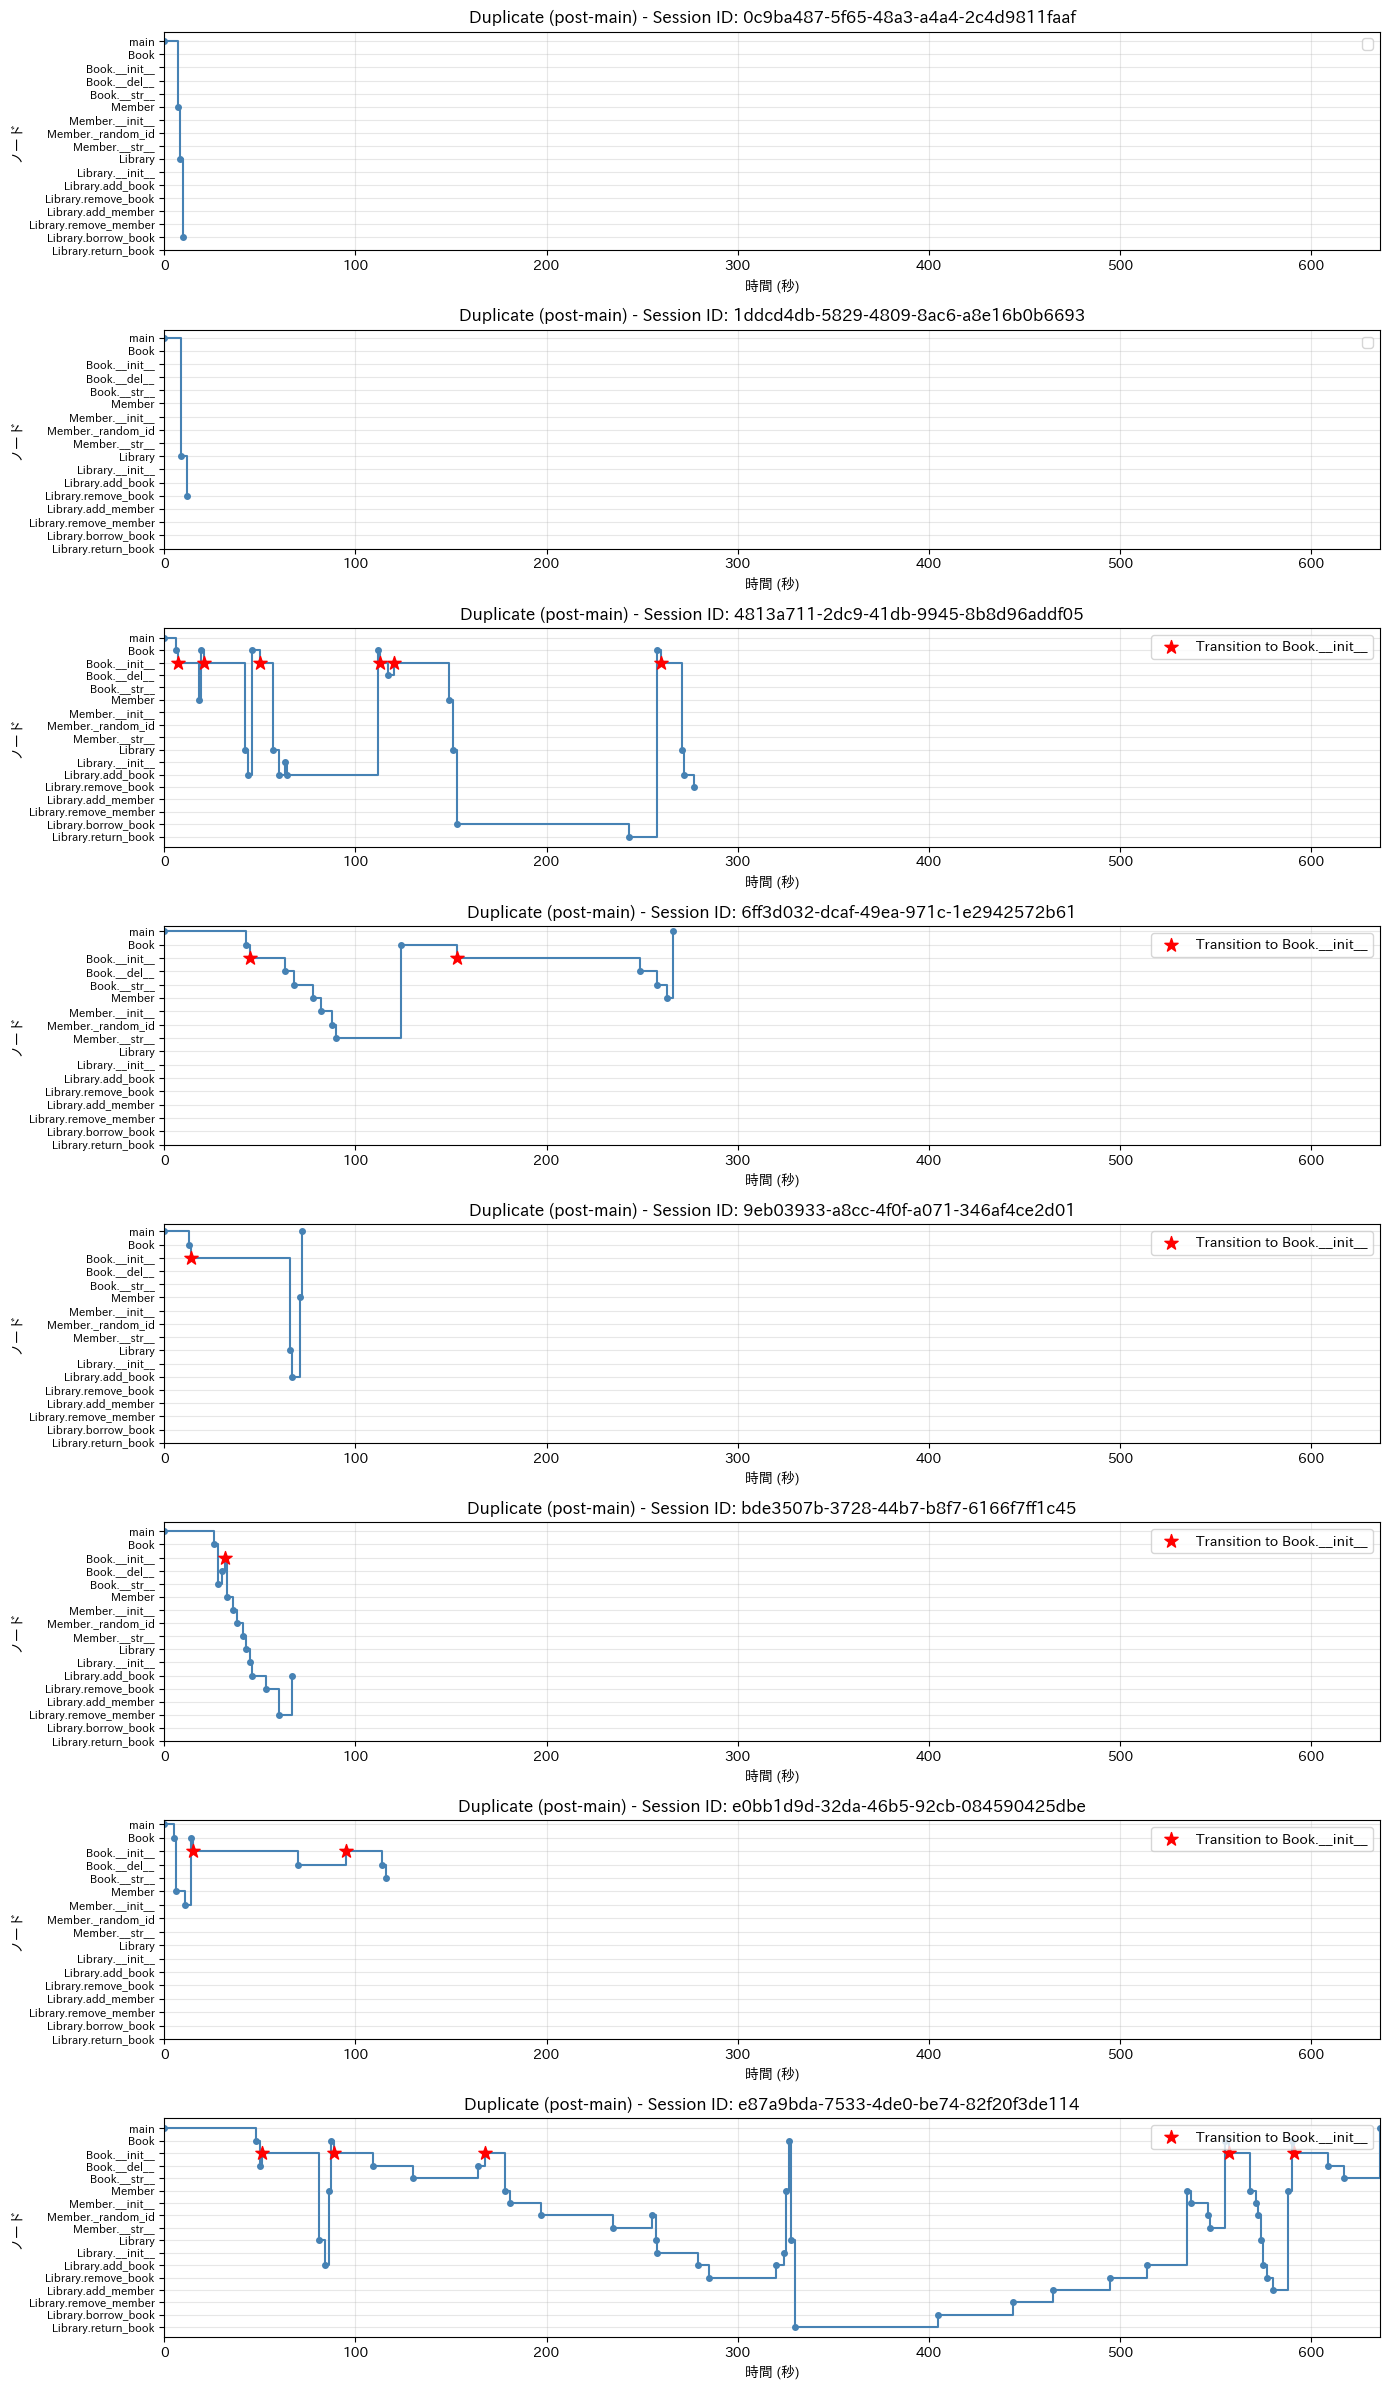

Exceed (post-main) タスクの総セッション数: 7


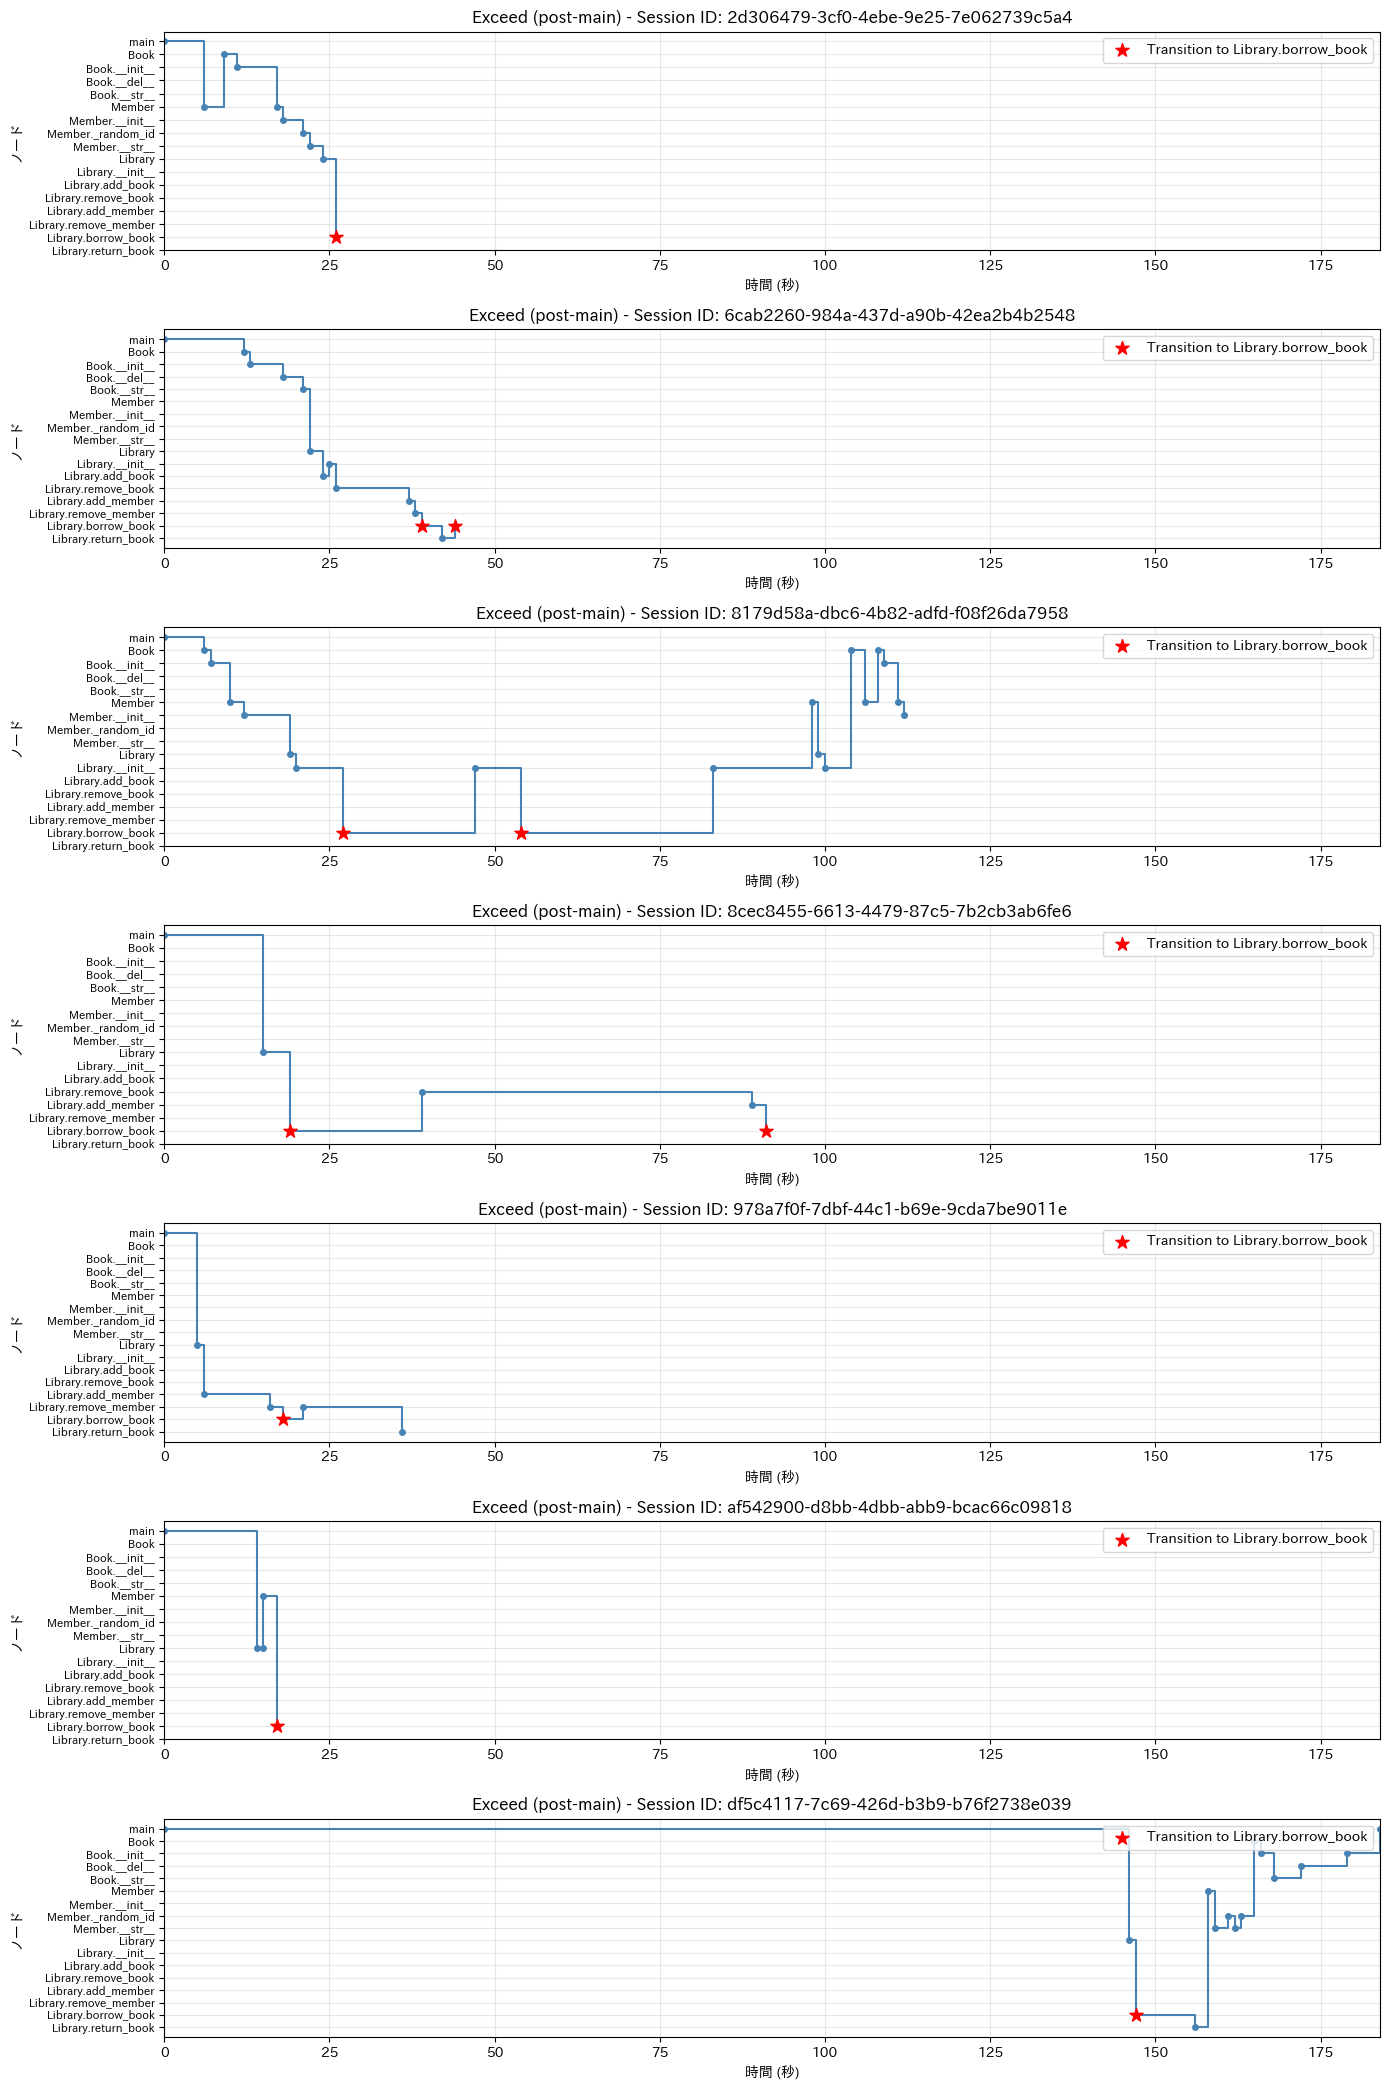

In [ ]:
# タスク別に df_post_main_logs を分割
df_post_main_logs_duplicate = df_post_main_logs[df_post_main_logs['task'] == 'duplicate']
df_post_main_logs_exceed = df_post_main_logs[df_post_main_logs['task'] == 'exceed']

print(f"Duplicate タスク: {len(df_post_main_logs_duplicate)} 行、セッション数: {df_post_main_logs_duplicate['session_id'].nunique()}")
print(f"Exceed タスク: {len(df_post_main_logs_exceed)} 行、セッション数: {df_post_main_logs_exceed['session_id'].nunique()}")

# Duplicate タスク - 最後の main.py 以降の遷移を可視化
if len(df_post_main_logs_duplicate) > 0:
    plot_task_transitions(df_post_main_logs_duplicate, 'Duplicate (post-main)', target_location='Book.__init__', n_sessions=8)
else:
    print("Duplicate タスク: データなし")

# Exceed タスク - 最後の main.py 以降の遷移を可視化
if len(df_post_main_logs_exceed) > 0:
    plot_task_transitions(df_post_main_logs_exceed, 'Exceed (post-main)', target_location='Library.borrow_book', n_sessions=7)
else:
    print("Exceed タスク: データなし")


## df_post_main_logs のヒートマップ可視化

Duplicate ヒートマップ: 17 location × 8 session
Exceed ヒートマップ: 17 location × 7 session


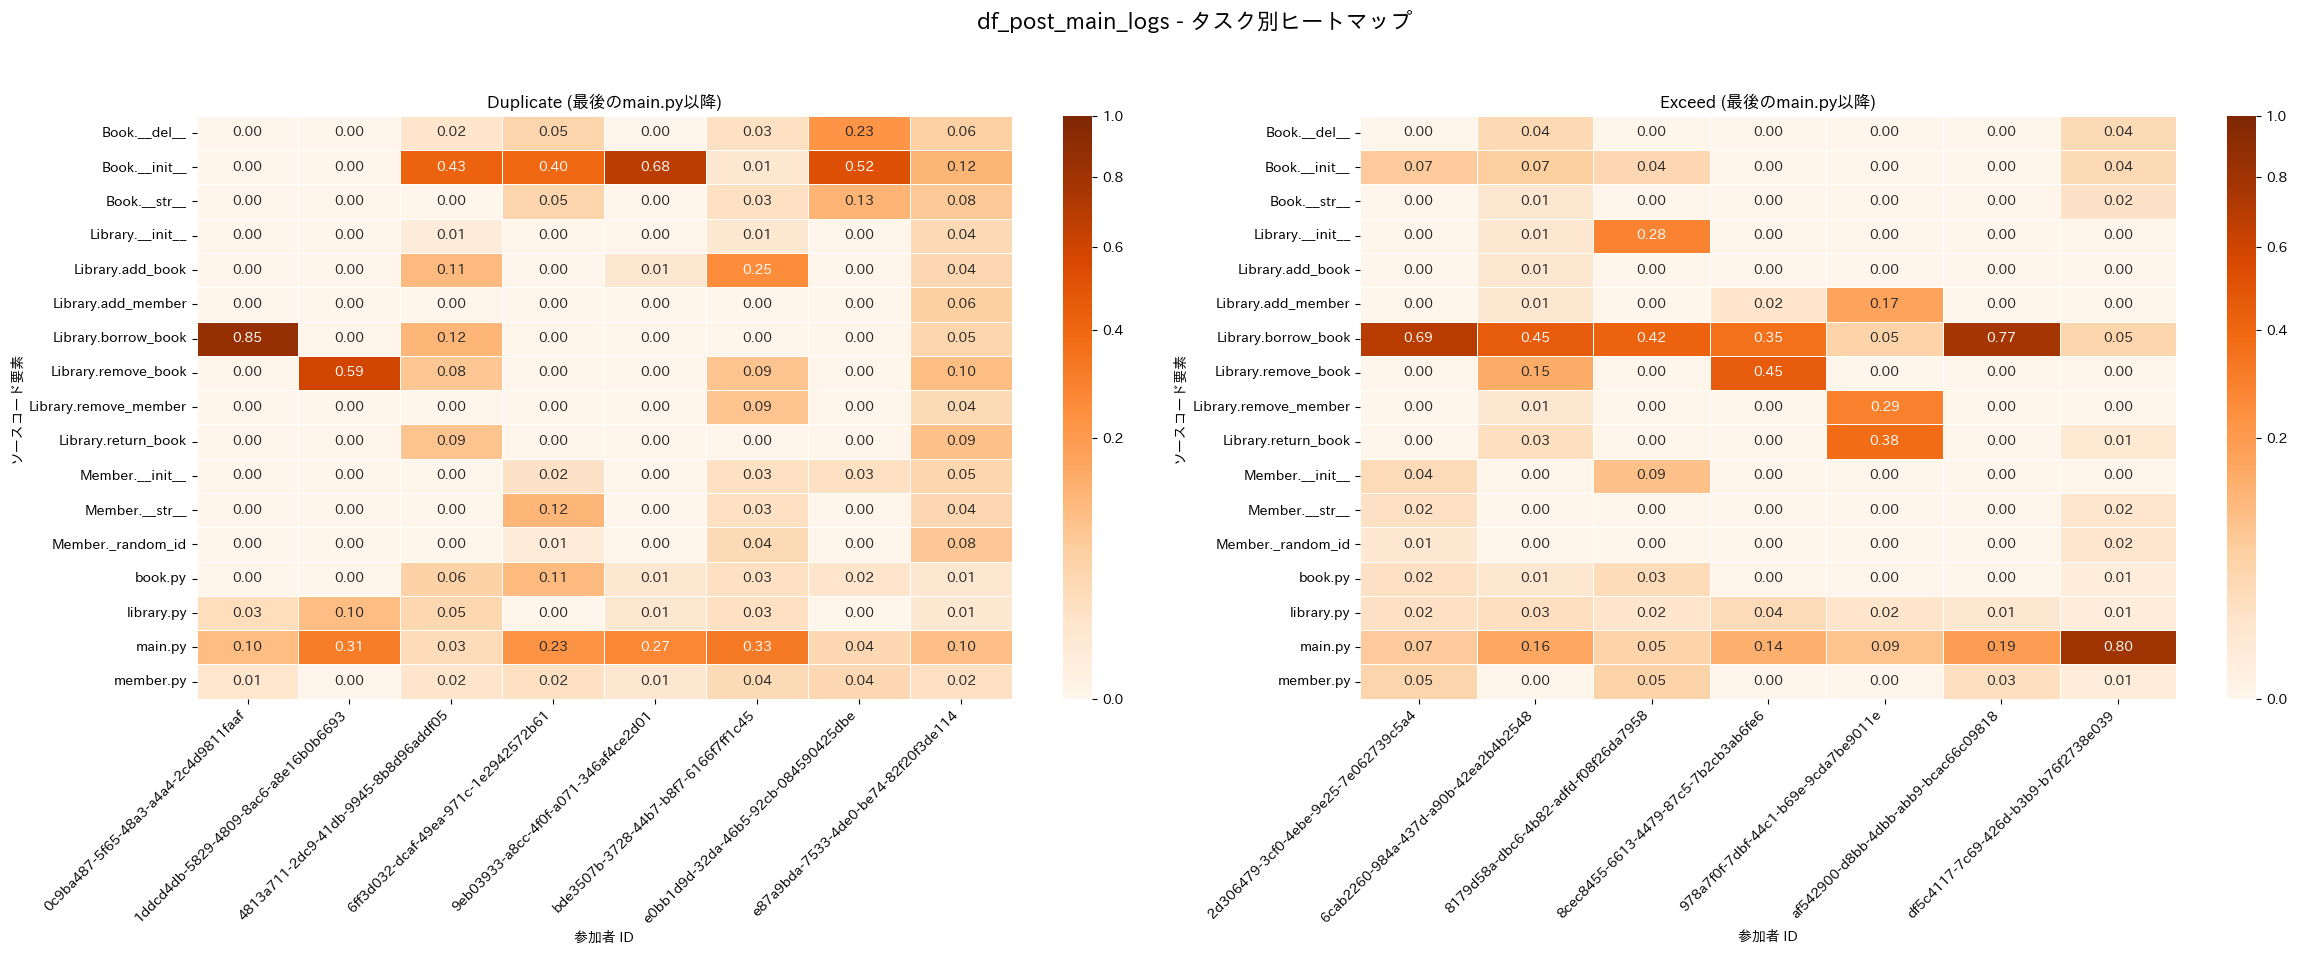


=== Duplicate (最後のmain.py以降) ===


,mean_probability
location,
Book.__del__,0.057513
Book.__init__,0.266715
Book.__str__,0.052480
Library.__init__,0.017254
Library.add_book,0.046010
Library.add_member,0.025881
Library.borrow_book,0.074766
Library.remove_book,0.068296
Library.remove_member,0.020129



=== Exceed (最後のmain.py以降) ===


,mean_probability
location,
Book.__del__,0.014205
Book.__init__,0.032670
Book.__str__,0.007102
Library.__init__,0.048295
Library.add_book,0.001420
Library.add_member,0.018466
Library.borrow_book,0.350852
Library.remove_book,0.086648
Library.remove_member,0.025568


In [ ]:
# df_post_main_logs を location × session_id で集計
df_post_main_heatmap_duplicate = df_post_main_logs_duplicate.groupby(['session_id', 'location'])['stay_time'].sum().unstack(fill_value=0).T
df_post_main_heatmap_exceed = df_post_main_logs_exceed.groupby(['session_id', 'location'])['stay_time'].sum().unstack(fill_value=0).T

print(f"Duplicate ヒートマップ: {df_post_main_heatmap_duplicate.shape[0]} location × {df_post_main_heatmap_duplicate.shape[1]} session")
print(f"Exceed ヒートマップ: {df_post_main_heatmap_exceed.shape[0]} location × {df_post_main_heatmap_exceed.shape[1]} session")

# 平均訪問割合を計算
mean_prob_post_main_duplicate, probs_post_main_duplicate = calculate_mean_probability(df_post_main_heatmap_duplicate)
mean_prob_post_main_exceed, probs_post_main_exceed = calculate_mean_probability(df_post_main_heatmap_exceed)

# ヒートマップを作成
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Duplicate
plot_heatmap_on_ax(axes[0], probs_post_main_duplicate, 'Duplicate (最後のmain.py以降)')

# Exceed
plot_heatmap_on_ax(axes[1], probs_post_main_exceed, 'Exceed (最後のmain.py以降)')

fig.suptitle('df_post_main_logs - タスク別ヒートマップ', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 平均訪問割合を表示
print("\n=== Duplicate (最後のmain.py以降) ===")
display(mean_prob_post_main_duplicate)

print("\n=== Exceed (最後のmain.py以降) ===")
display(mean_prob_post_main_exceed)

# 必要に応じてCSVに保存
mean_prob_post_main_duplicate.to_csv('../data/mean_probability_post_main_duplicate.csv')
mean_prob_post_main_exceed.to_csv('../data/mean_probability_post_main_exceed.csv')


# タスク別セッション滞在時間統計

In [ ]:
# タスク別のセッションごと滞在時間を計算
# Duplicate タスクのセッションごとの合計滞在時間
df_experiment_duplicate_sessions = df_experiment[df_experiment['task'] == 'duplicate']
session_total_stay_time_duplicate = df_experiment_duplicate_sessions.groupby('session_id')['stay_time'].sum()

# Exceed タスクのセッションごとの合計滞在時間
df_experiment_exceed_sessions = df_experiment[df_experiment['task'] == 'exceed']
session_total_stay_time_exceed = df_experiment_exceed_sessions.groupby('session_id')['stay_time'].sum()

# Duplicate タスクの統計
print("=" * 60)
print("Duplicate タスク - セッションごとの合計滞在時間")
print("=" * 60)
print(f"セッション数: {len(session_total_stay_time_duplicate)}")
print(f"平均: {session_total_stay_time_duplicate.mean():.2f} 秒 ({session_total_stay_time_duplicate.mean()/60:.2f} 分)")
print(f"中央値: {session_total_stay_time_duplicate.median():.2f} 秒 ({session_total_stay_time_duplicate.median()/60:.2f} 分)")
print(f"標準偏差: {session_total_stay_time_duplicate.std():.2f} 秒 ({session_total_stay_time_duplicate.std()/60:.2f} 分)")
print(f"最小値: {session_total_stay_time_duplicate.min():.2f} 秒")
print(f"最大値: {session_total_stay_time_duplicate.max():.2f} 秒")
print()

# Exceed タスクの統計
print("=" * 60)
print("Exceed タスク - セッションごとの合計滞在時間")
print("=" * 60)
print(f"セッション数: {len(session_total_stay_time_exceed)}")
print(f"平均: {session_total_stay_time_exceed.mean():.2f} 秒 ({session_total_stay_time_exceed.mean()/60:.2f} 分)")
print(f"中央値: {session_total_stay_time_exceed.median():.2f} 秒 ({session_total_stay_time_exceed.median()/60:.2f} 分)")
print(f"標準偏差: {session_total_stay_time_exceed.std():.2f} 秒 ({session_total_stay_time_exceed.std()/60:.2f} 分)")
print(f"最小値: {session_total_stay_time_exceed.min():.2f} 秒")
print(f"最大値: {session_total_stay_time_exceed.max():.2f} 秒")
print()

Duplicate タスク - セッションごとの合計滞在時間
セッション数: 8
平均: 924.75 秒 (15.41 分)
中央値: 941.50 秒 (15.69 分)
標準偏差: 407.09 秒 (6.78 分)
最小値: 389.00 秒
最大値: 1454.00 秒

Exceed タスク - セッションごとの合計滞在時間
セッション数: 7
平均: 1131.71 秒 (18.86 分)
中央値: 1337.00 秒 (22.28 分)
標準偏差: 677.61 秒 (11.29 分)
最小値: 236.00 秒
最大値: 2124.00 秒



# 相関

In [84]:
def compute_target_ratio_correlation(df, task, target_location):
    from scipy.stats import pearsonr
    
    df_task = df[df['task'] == task]
    # セッションごとの滞在時間合計
    session_total = df_task.groupby('session_id')['stay_time'].sum()
    # target location の滞在時間
    target_time = (
        df_task[df_task['location'] == target_location]
        .groupby('session_id')['stay_time']
        .sum()
    )
    # 訪問割合（存在しない場合は0で補完）
    target_ratio = target_time.reindex(session_total.index, fill_value=0) / session_total
    stats = pd.DataFrame({
        'total_stay_time': session_total,
        'target_ratio': target_ratio,
    })
    
    # Pearson相関係数とp値を計算
    corr, p_value = pearsonr(stats['total_stay_time'], stats['target_ratio'])
    
    return corr, p_value, stats

# Duplicate / Exceed それぞれ計算
corr_duplicate, p_duplicate, stats_duplicate = compute_target_ratio_correlation(
    df_experiment_trimmed, task='duplicate', target_location='Book.__init__'
)
corr_exceed, p_exceed, stats_exceed = compute_target_ratio_correlation(
    df_experiment_trimmed, task='exceed', target_location='Library.borrow_book'
)

print('Duplicate タスク:')
print(f"  相関係数: {corr_duplicate:.4f}")
print(f"  p値: {p_duplicate:.4e}")
display(stats_duplicate.head())

print('\nExceed タスク:')
print(f"  相関係数: {corr_exceed:.4f}")
print(f"  p値: {p_exceed:.4e}")
display(stats_exceed.head())

Duplicate タスク:
  相関係数: -0.6017
  p値: 1.1457e-01


,total_stay_time,target_ratio
session_id,,
0c9ba487-5f65-48a3-a4a4-2c4d9811faaf,1204.0,0.111296
1ddcd4db-5829-4809-8ac6-a8e16b0b6693,300.0,0.126667
4813a711-2dc9-41db-9945-8b8d96addf05,1219.0,0.201805
6ff3d032-dcaf-49ea-971c-1e2942572b61,1015.0,0.111330
9eb03933-a8cc-4f0f-a071-346af4ce2d01,598.0,0.267559



Exceed タスク:
  相関係数: -0.3466
  p値: 4.4628e-01


,total_stay_time,target_ratio
session_id,,
2d306479-3cf0-4ebe-9e25-7e062739c5a4,1273.0,0.274156
6cab2260-984a-437d-a90b-42ea2b4b2548,443.0,0.237020
8179d58a-dbc6-4b82-adfd-f08f26da7958,1309.0,0.432391
8cec8455-6613-4479-87c5-7b2cb3ab6fe6,1541.0,0.625568
978a7f0f-7dbf-44c1-b69e-9cda7be9011e,612.0,0.256536


In [92]:
# セッションごとの stay_time 合計と experience の相関分析（タスク別）
from scipy.stats import pearsonr

# session_id ごとの experience と task を取得
session_info = df_session_task_unique.drop_duplicates(subset='session_id')[['session_id', 'experience', 'task']].set_index('session_id')

# 各タスクについて相関を計算
for task in ['duplicate', 'exceed']:
    print(f"\n{'='*60}")
    print(f"タスク: {task}")
    print('='*60)
    
    # そのタスクのセッションを抽出
    task_sessions = df_experiment[df_experiment['task'] == task]['session_id'].unique()
    task_session_stay = df_experiment[df_experiment['task'] == task].groupby('session_id')['stay_time'].sum()
    
    # 対応する experience を取得
    correlation_data = pd.DataFrame({
        'total_stay_time': task_session_stay,
        'experience': session_info.loc[task_session_stay.index, 'experience']
    }).dropna()
    
    print(f"分析対象セッション数: {len(correlation_data)}")
    print(f"\n統計情報:")
    print(correlation_data.describe())
    
    # Pearson相関係数とp値を計算
    if len(correlation_data) > 1:
        corr, p_value = pearsonr(correlation_data['total_stay_time'], correlation_data['experience'])
        print(f"\n相関分析結果 (stay_time vs experience):")
        print(f"  相関係数: {corr:.4f}")
        print(f"  p値: {p_value:.4e}")
        
        # 解釈
        if p_value < 0.05:
            print(f"  ✓ 統計的に有意な相関があります (p < 0.05)")
        else:
            print(f"  ✗ 統計的に有意な相関はありません (p >= 0.05)")
    else:
        print("相関計算に必要なデータが不足しています")


タスク: duplicate
分析対象セッション数: 8

統計情報:
       total_stay_time  experience
count         8.000000     8.00000
mean        924.750000     1.12500
std         407.094145     0.64087
min         389.000000     0.50000
25%         618.500000     0.50000
50%         941.500000     1.00000
75%        1255.000000     1.62500
max        1454.000000     2.00000

相関分析結果 (stay_time vs experience):
  相関係数: -0.0459
  p値: 9.1414e-01
  ✗ 統計的に有意な相関はありません (p >= 0.05)

タスク: exceed
分析対象セッション数: 7

統計情報:
       total_stay_time  experience
count         7.000000    7.000000
mean       1131.714286    2.642857
std         677.613389    1.749149
min         236.000000    1.000000
25%         591.000000    1.500000
50%        1337.000000    2.000000
75%        1521.500000    3.250000
max        2124.000000    6.000000

相関分析結果 (stay_time vs experience):
  相関係数: -0.3142
  p値: 4.9258e-01
  ✗ 統計的に有意な相関はありません (p >= 0.05)


In [94]:
# session_id ごとの experience と correct の関係をロジスティック回帰で検討
try:
    import statsmodels.api as sm
    
    # セッション単位のデータを作成
    df_logit = df_session_task_unique[['session_id', 'experience', 'correct']].drop_duplicates('session_id').copy()
    df_logit = df_logit.dropna(subset=['experience', 'correct'])
    df_logit['correct'] = df_logit['correct'].astype(int)
    
    print(f"分析対象セッション数: {len(df_logit)}")
    display(df_logit.head())
    
    # 説明変数と目的変数
    X = sm.add_constant(df_logit['experience'])
    y = df_logit['correct']
    
    # ロジスティック回帰
    model = sm.Logit(y, X).fit(disp=False)
    print(model.summary())
    
    # オッズ比を表示
    odds_ratio = model.params.apply(np.exp)
    print("\nオッズ比:")
    print(odds_ratio)
except Exception as e:
    print("statsmodels が必要です。インストール後に再実行してください。")
    print(f"エラー: {e}")

分析対象セッション数: 15


,session_id,experience,correct
15,bde3507b-3728-44b7-b8f7-6166f7ff1c45,2.0,1
20,af542900-d8bb-4dbb-abb9-bcac66c09818,1.0,1
21,6ff3d032-dcaf-49ea-971c-1e2942572b61,1.5,1
33,df5c4117-7c69-426d-b3b9-b76f2738e039,1.0,0
38,0c9ba487-5f65-48a3-a4a4-2c4d9811faaf,1.0,1


                           Logit Regression Results                           
Dep. Variable:                correct   No. Observations:                   15
Model:                          Logit   Df Residuals:                       13
Method:                           MLE   Df Model:                            1
Date:                Sat, 31 Jan 2026   Pseudo R-squ.:                 0.02425
Time:                        20:33:20   Log-Likelihood:                -9.3162
converged:                       True   LL-Null:                       -9.5477
Covariance Type:            nonrobust   LLR p-value:                    0.4962
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1807      0.943      0.192      0.848      -1.667       2.029
experience     0.2975      0.474      0.628      0.530      -0.631       1.226

オッズ比:
const         1.198067
experience    1.346549

# JSD Results 可視化 (dataset=trimmed)

In [42]:
# JSD Results のCSVを読み込み
df_jsd = pd.read_csv('../data/jsd_results.csv')

# dataset=trimmed のデータのみを抽出
df_jsd_trimmed = df_jsd[df_jsd['dataset'] == 'trimmed'].copy()

print(f"dataset=trimmed のデータ数: {len(df_jsd_trimmed)}")
display(df_jsd_trimmed)

dataset=trimmed のデータ数: 36


,dataset,model,task,condition,jsd
36,trimmed,topology,duplicate,all,0.280
37,trimmed,topology,duplicate,true,0.300
38,trimmed,topology,duplicate,false,0.264
39,trimmed,topology,exceed,all,0.363
40,trimmed,topology,exceed,true,0.491
41,trimmed,topology,exceed,false,0.324
42,trimmed,cosine,duplicate,all,0.216
43,trimmed,cosine,duplicate,true,0.228
44,trimmed,cosine,duplicate,false,0.223
45,trimmed,cosine,exceed,all,0.252


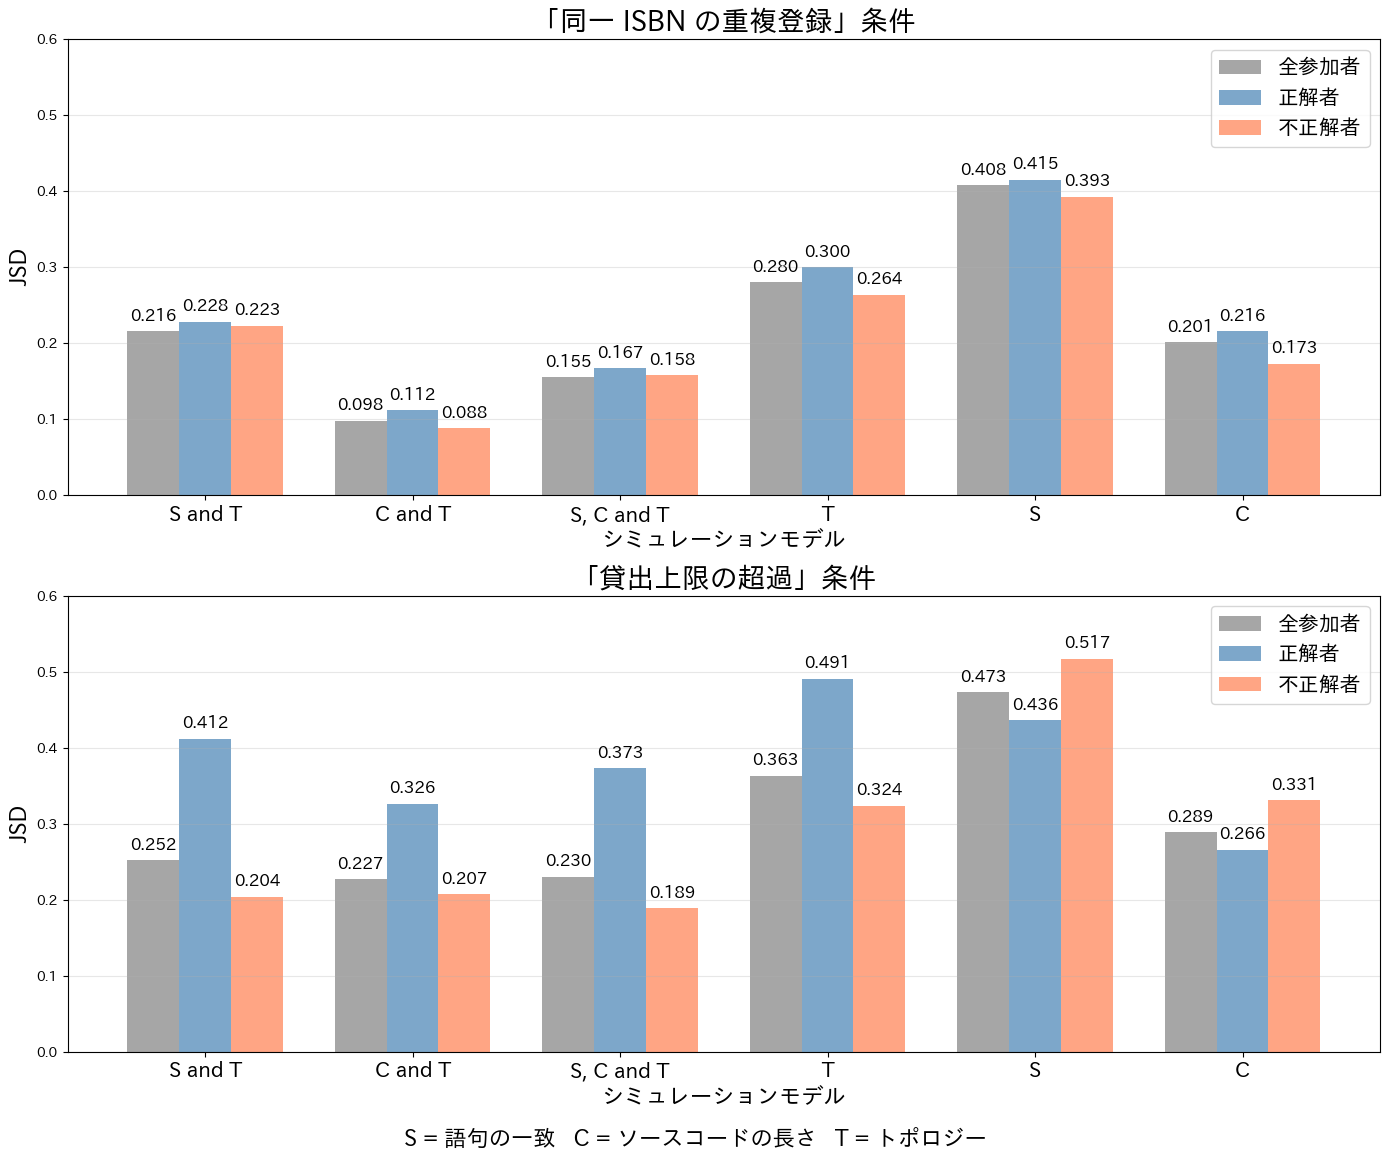

In [45]:
# タスク別、condition別、model別にJSDを棒グラフで可視化
# モデルの順序を固定
model_order = ['cosine', 'chunk', 'cosine_chunk_avg', 'topology', 'node_similarity', 'node_chunks']

# モデルラベルの日本語表記
model_labels = {
    'cosine': 'S and T',
    'chunk': 'C and T',
    'cosine_chunk_avg': 'S, C and T',
    'topology': 'T',
    'node_similarity': 'S',
    'node_chunks': 'C'
}

# タスクラベルの日本語表記
task_labels = {
    'duplicate': '「同一 ISBN の重複登録」条件',
    'exceed': '「貸出上限の超過」条件'
}

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

tasks = ['duplicate', 'exceed']
conditions = ['all', 'true', 'false']
condition_labels = {'true': '正解者', 'false': '不正解者', 'all': '全参加者'}
colors = {'true': 'steelblue', 'false': 'coral', 'all': 'gray'}

for task_idx, task in enumerate(tasks):
    ax = axes[task_idx]
    
    # 各conditionのデータを取得
    data_by_condition = {}
    for condition in conditions:
        df_subset = df_jsd_trimmed[
            (df_jsd_trimmed['task'] == task) & 
            (df_jsd_trimmed['condition'] == condition)
        ].copy()
        
        # モデルの順序を固定
        df_subset['model'] = pd.Categorical(df_subset['model'], categories=model_order, ordered=True)
        df_subset = df_subset.sort_values('model').set_index('model')
        data_by_condition[condition] = df_subset
    
    # 棒の位置を計算
    x = np.arange(len(model_order))
    width = 0.25
    
    # 各conditionの棒グラフを作成
    for cond_idx, condition in enumerate(conditions):
        df_data = data_by_condition[condition]
        # model_orderに従ってjsd値を取得（存在しない場合は0）
        jsd_values = [df_data.loc[model, 'jsd'] if model in df_data.index else 0 
                      for model in model_order]
        
        offset = width * (cond_idx - 1)
        bars = ax.bar(x + offset, jsd_values, width, 
                     label=condition_labels[condition], 
                     color=colors[condition], alpha=0.7)
        
        # 各棒の上に値を表示
        for i, (bar, value) in enumerate(zip(bars, jsd_values)):
            if value > 0:
                ax.text(bar.get_x() + bar.get_width()/2, value + 0.01, 
                       f'{value:.3f}', ha='center', va='bottom', fontsize=12)
    
    # X軸の設定（日本語ラベルを使用）
    ax.set_xticks(x)
    ax.set_xticklabels([model_labels[m] for m in model_order], fontsize=15)
    
    # Y軸の範囲を0-0.6に設定
    ax.set_ylim(0, 0.6)
    
    # グリッドを追加
    ax.grid(True, alpha=0.3, axis='y')
    
    # タイトルとラベルを設定（日本語ラベルを使用）
    ax.set_title(f'{task_labels[task]}', fontsize=20, fontweight='bold')
    ax.set_ylabel('JSD', fontsize=16)
    ax.set_xlabel('シミュレーションモデル', fontsize=16)
    
    # 凡例を追加
    ax.legend(loc='upper right', fontsize=15)

# fig.suptitle('JSD Results (dataset=trimmed)', fontsize=16, fontweight='bold')
fig.text(0.5, 0.01, 'S = 語句の一致   C = ソースコードの長さ   T = トポロジー', ha='center', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()


# トポロジー隣接行列の可視化

In [58]:
# トポロジー隣接行列を読み込み
df_topology_matrix = pd.read_csv('../topology_matrix.csv', index_col=0)

# ノード名を置き換え
df_topology_matrix = df_topology_matrix.rename(
    index={'main': 'main.py', 'Book': 'book.py', 'Member': 'member.py', 'Library': 'library.py'},
    columns={'main': 'main.py', 'Book': 'book.py', 'Member': 'member.py', 'Library': 'library.py'}
)

print(f"隣接行列のサイズ: {df_topology_matrix.shape}")
print(f"ノード数: {len(df_topology_matrix)}")
display(df_topology_matrix)


隣接行列のサイズ: (17, 17)
ノード数: 17


,book.py,Book.__del__,Book.__init__,Book.__str__,library.py,Library.__init__,Library.add_book,Library.add_member,Library.borrow_book,Library.remove_book,Library.remove_member,Library.return_book,member.py,Member.__init__,Member.__str__,Member._random_id,main.py
book.py,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1
Book.__del__,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Book.__init__,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Book.__str__,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
library.py,0,0,0,0,1,1,1,1,1,1,1,1,0,0,0,0,1
Library.__init__,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
Library.add_book,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
Library.add_member,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
Library.borrow_book,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
Library.remove_book,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


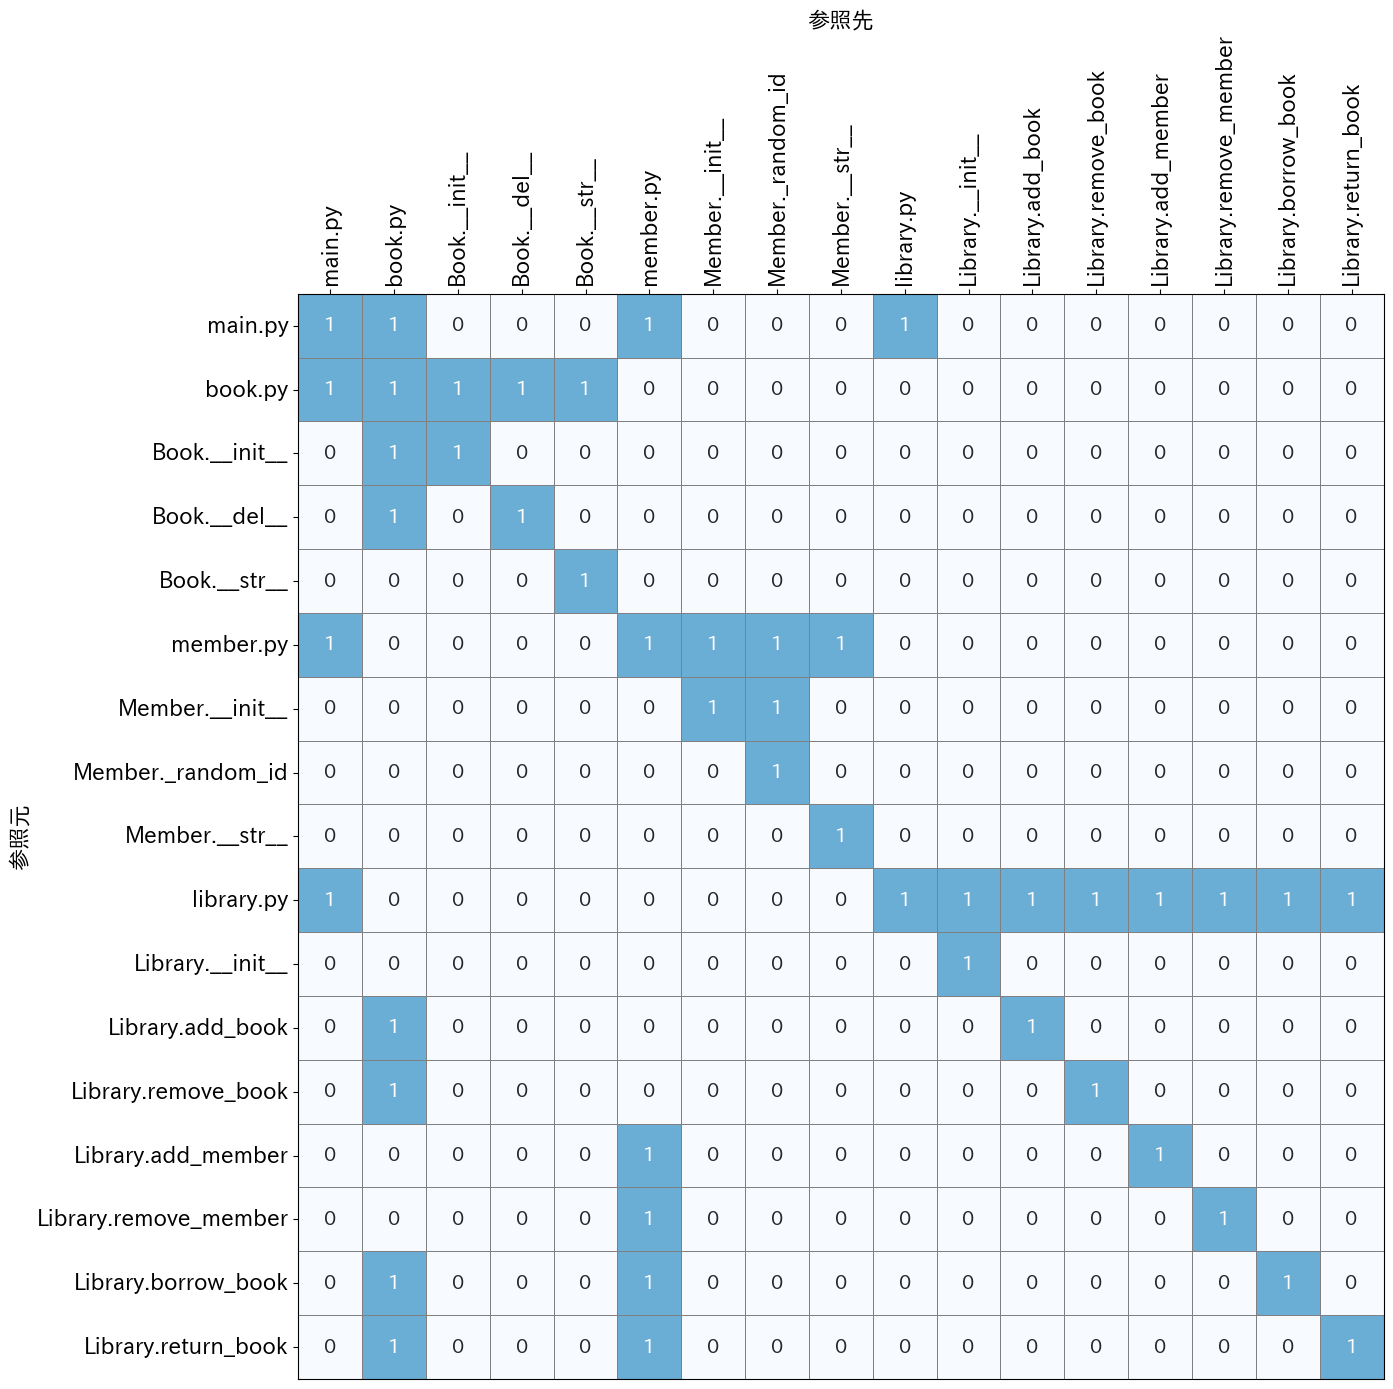

In [79]:
# 隣接行列をヒートマップとして可視化
# topology_orderに従ってDataFrameの行と列を並べ替え
df_topo_sorted = df_topology_matrix.copy()
# topology_orderに含まれるノードのみをフィルタリング
ordered_nodes = [node for node in topology_order if node in df_topo_sorted.index]
df_topo_sorted = df_topo_sorted.reindex(ordered_nodes, axis=0)
df_topo_sorted = df_topo_sorted.reindex(ordered_nodes, axis=1)

fig, ax = plt.subplots(figsize=(14, 14))

sns.heatmap(
    df_topo_sorted,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax,
    linewidths=0.5,
    linecolor='gray',
    square=True,
    vmin=0,
    vmax=1,
    cbar=False,
    annot_kws={'size': 14}
)

# ax.set_title('トポロジー隣接行列', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('参照先', fontsize=16)
ax.set_ylabel('参照元', fontsize=16)

# 枠線を表示
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

# X軸のラベルを上に配置
ax.xaxis.set_label_position("top")
ax.xaxis.tick_top()

# X軸とY軸のラベルを回転
plt.xticks(rotation=90, fontsize=16)
plt.yticks(rotation=0, fontsize=16)

plt.tight_layout()
plt.show()
